# 🏙️ Airbnb NYC Price Prediction — End-to-End Machine Learning Pipeline

---

| Field | Details |
|---|---|
| **Project** | Nightly Price Prediction for Airbnb Listings — New York City |
| **Dataset** | NYC Airbnb Open Data 2019 (~49,000 listings, 16 features) |
| **Target Variable** | `price` — nightly listing price in USD |
| **Best Model** | XGBoost / Random Forest (ensemble) |
| **Author** | Robert Cicero Son |
| **Date** | 2024 |

---

## Pipeline Overview

```
Raw Data → Preprocessing & Cleaning → EDA → Feature Engineering
         → Feature Selection → Model Training → Evaluation
         → Hyperparameter Tuning → Best Model Save → Prediction
```

**Sections in this notebook:**

| # | Section | Description |
|---|---|---|
| 1 | Imports & Setup | Libraries, global config, random seeds |
| 2 | Data Loading | Load CSV/XLSX, shape, dtypes, missing summary |
| 3 | Preprocessing | Drop irrelevant cols, impute, remove outliers, encode |
| 4 | Exploratory Data Analysis | Univariate, Bivariate, Multivariate, Geographic |
| 5 | Feature Engineering | New predictive features from existing columns |
| 6 | Feature Selection | Mutual Information + RF Importance |
| 7 | Model Training | 7 algorithms, cross-validation, metrics |
| 8 | Hyperparameter Tuning | GridSearchCV on top model |
| 9 | Save Best Model | Persist model + scaler + feature list |
| 10 | Interactive Prediction | User input → predicted price |

> **Note on Model Performance:** Airbnb price prediction is inherently noisy because hosts set prices
> based on factors not captured in this dataset (amenities, photos, décor, dynamic pricing tools).
> R² values in the 0.55–0.65 range are typical and considered good for this problem domain.


## 1. Imports & Configuration

### Why this matters
Before any analysis begins, we establish a clean, reproducible environment:
- **All libraries are imported once** at the top — this makes dependencies visible and avoids
  hidden re-imports scattered through the notebook.
- **Random seeds are fixed** (`RANDOM_STATE = 42`) so every run produces identical results,
  a critical requirement for reproducible research.
- **Plotting defaults** are set globally so every chart follows a consistent visual style.
- We detect **optional libraries** (XGBoost, LightGBM) gracefully so the notebook works even
  if those packages are not installed.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1 — IMPORTS & GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

# Core
import os, sys, time
import numpy as np
import pandas as pd
from scipy import stats

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn — preprocessing
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, GridSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Scikit-learn — models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor)

# Scikit-learn — metrics & selection
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.feature_selection import mutual_info_regression, SelectFromModel

# Optional boosting libraries
try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠  XGBoost not installed — skipping.")

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠  LightGBM not installed — skipping.")

import joblib

# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
CV_FOLDS      = 5
np.random.seed(RANDOM_STATE)

# ── Matplotlib / Seaborn style ────────────────────────────────────────────────
PALETTE  = 'tab10'
BG_COLOR = '#FAFAFA'
plt.rcParams.update({
    'figure.dpi':        130,
    'figure.facecolor':  'white',
    'axes.facecolor':    BG_COLOR,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.labelsize':    11,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'font.family':       'DejaVu Sans',
})
sns.set_palette(PALETTE)

print("✅ All libraries loaded successfully.")
print(f"   numpy  {np.__version__}  |  pandas  {pd.__version__}")
print(f"   XGBoost: {'✓' if XGBOOST_AVAILABLE else '✗'}  |  LightGBM: {'✓' if LIGHTGBM_AVAILABLE else '✗'}")


⚠  LightGBM not installed — skipping.
✅ All libraries loaded successfully.
   numpy  1.26.4  |  pandas  2.1.3
   XGBoost: ✓  |  LightGBM: ✗


## 2. Data Loading & Basic Description

### What we do here
1. **Auto-detect the dataset file** — the code searches for common filenames in the working
   directory. If none is found, it downloads the public NYC Airbnb 2019 dataset automatically.
2. **Display shape and dtypes** — understanding what types of columns we have (numeric vs
   categorical vs datetime) determines every downstream step.
3. **Inspect missing values** — we quantify both the count and percentage of nulls per column,
   since different imputation strategies apply depending on the missing rate and column type.
4. **Statistical summary** — `.describe()` gives us the range, quartiles, and standard deviation
   of every numeric column, flagging obvious data quality issues (e.g., price = $0 or
   minimum_nights = 1000).

### Dataset Dictionary

| Column | Type | Description |
|---|---|---|
| `id` | int | Unique listing identifier |
| `name` | str | Free-text listing title |
| `host_id` | int | Unique host identifier |
| `host_name` | str | Host first name |
| `neighbourhood_group` | str | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | str | Specific neighbourhood within borough |
| `latitude` | float | GPS latitude |
| `longitude` | float | GPS longitude |
| `room_type` | str | Entire home/apt, Private room, Shared room |
| `price` | int | **TARGET** — nightly price in USD |
| `minimum_nights` | int | Minimum booking duration |
| `number_of_reviews` | int | Total reviews received |
| `last_review` | date | Date of most recent review |
| `reviews_per_month` | float | Average monthly reviews |
| `calculated_host_listings_count` | int | Total listings this host has |
| `availability_365` | int | Days available per year |


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2A — LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

# Auto-detect file in working directory
CANDIDATE_FILES = [
    'AB_NYC_2019.csv', 'airbnb.csv', 'airbnb.xlsx',
    'dataset.csv', 'dataset.xlsx', 'ab_nyc_2019.csv'
]

DATA_FILE = None
for fname in CANDIDATE_FILES:
    if os.path.exists(fname):
        DATA_FILE = fname
        break

if DATA_FILE is None:
    print("📥 No local file found — downloading NYC Airbnb 2019 dataset...")
    import urllib.request
    url = ("https://raw.githubusercontent.com/dsrscientist/"
           "dataset1/master/new-york-city-airbnb-open-data/AB_NYC_2019.csv")
    urllib.request.urlretrieve(url, 'AB_NYC_2019.csv')
    DATA_FILE = 'AB_NYC_2019.csv'
    print(f"   → Saved to: {DATA_FILE}")

# Load
t0 = time.time()
if DATA_FILE.endswith('.csv'):
    df_raw = pd.read_csv(DATA_FILE)
else:
    df_raw = pd.read_excel(DATA_FILE)
elapsed = time.time() - t0

print(f"✅ Dataset loaded: {DATA_FILE}  ({elapsed:.2f}s)")
print(f"   Rows    : {df_raw.shape[0]:,}")
print(f"   Columns : {df_raw.shape[1]}")
print(f"   Memory  : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")


✅ Dataset loaded: AB_NYC_2019.csv  (0.25s)
   Rows    : 48,895
   Columns : 16
   Memory  : 24.6 MB


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2B — FIRST LOOK
# ─────────────────────────────────────────────────────────────────────────────
print("First 5 rows:")
df_raw.head()


First 5 rows:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2C — DATA TYPES & NON-NULL COUNTS
# ─────────────────────────────────────────────────────────────────────────────
print("Column info:")
df_raw.info()


Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review        

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2D — STATISTICAL SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("Numeric columns — descriptive statistics:")
df_raw.describe().T.round(2)


Numeric columns — descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
id,48895.0,19017143.24,10983108.39,2539.00,9471945.00,19677284.00,2.915218e+07,3.648724e+07
host_id,48895.0,67620010.65,78610967.03,2438.00,7822033.00,30793816.00,1.074344e+08,2.743213e+08
latitude,48895.0,40.73,0.05,40.50,40.69,40.72,4.076000e+01,4.091000e+01
longitude,48895.0,-73.95,0.05,-74.24,-73.98,-73.96,-7.394000e+01,-7.371000e+01
price,48895.0,152.72,240.15,0.00,69.00,106.00,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.03,20.51,1.00,1.00,3.00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,23.27,44.55,0.00,1.00,5.00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.37,1.68,0.01,0.19,0.72,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.14,32.95,1.00,1.00,1.00,2.000000e+00,3.270000e+02
availability_365,48895.0,112.78,131.62,0.00,0.00,45.00,2.270000e+02,3.650000e+02


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2E — MISSING VALUE AUDIT
# ─────────────────────────────────────────────────────────────────────────────
missing      = df_raw.isnull().sum()
missing_pct  = (missing / len(df_raw) * 100).round(2)
dtype_map    = df_raw.dtypes.astype(str)
missing_df   = pd.DataFrame({
    'Dtype'         : dtype_map,
    'Missing Count' : missing,
    'Missing %'     : missing_pct,
    'Action'        : ''
})
# Annotate proposed action
missing_df.loc['reviews_per_month', 'Action'] = 'Fill with 0 (no reviews → 0/month)'
missing_df.loc['last_review',       'Action'] = 'Drop column (date string, not predictive)'
missing_df.loc['name',              'Action'] = 'Drop column (free-text, high cardinality)'
missing_df.loc['host_name',         'Action'] = 'Drop column (PII, not predictive)'

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f"Columns with missing data: {len(missing_df)}")
display(missing_df.style
        .background_gradient(cmap='OrRd', subset=['Missing %'])
        .set_properties(**{'font-size': '11px'}))

# Price summary
print(f"\nPrice range  : ${df_raw['price'].min():,} – ${df_raw['price'].max():,}")
print(f"Price mean   : ${df_raw['price'].mean():.2f}")
print(f"Price median : ${df_raw['price'].median():.2f}")
print(f"Price = $0   : {(df_raw['price'] == 0).sum()} rows (invalid — to be removed)")


Columns with missing data: 4


,Dtype,Missing Count,Missing %,Action
last_review,object,10052,20.560000,"Drop column (date string, not predictive)"
reviews_per_month,float64,10052,20.560000,Fill with 0 (no reviews → 0/month)
host_name,object,21,0.040000,"Drop column (PII, not predictive)"
name,object,16,0.030000,"Drop column (free-text, high cardinality)"



Price range  : $0 – $10,000
Price mean   : $152.72
Price median : $106.00
Price = $0   : 11 rows (invalid — to be removed)


## 3. Data Preprocessing & Cleaning

### Why preprocessing matters
Raw data is rarely analysis-ready. The steps below address three categories of issues:

#### 3.1 Irrelevant / Leaky Columns
Columns like `id`, `name`, `host_id`, and `host_name` are either unique identifiers that carry no
generalizable signal, or free-text fields that would require NLP to be useful. Keeping them would
bloat the feature space without improving predictions. `last_review` is a date string that would
need special parsing — we drop it here (the derived `reviews_per_month` already captures its signal).

#### 3.2 Missing Value Imputation
- **`reviews_per_month`** is null whenever `number_of_reviews == 0`. This is a structured missingness
  — a listing with zero reviews has zero reviews per month. We fill with `0` (not the column mean),
  because using the mean would incorrectly suggest these listings are actively reviewed.

#### 3.3 Outlier Handling
- **`price`**: Zero-priced listings are data errors or test listings. Extreme prices (> 99.5th
  percentile, i.e., > ~$800/night) are statistically valid but so rare that they would distort model
  training. We remove them entirely rather than capping (Winsorizing), because capping would still
  leave implausible values in the training set.
- **`minimum_nights`**: Values above the 99th percentile (often 365 nights or more) are monthly/annual
  rental contracts, a fundamentally different market from short-term stays. We exclude them.

#### 3.4 Categorical Encoding
Two strategies are applied based on cardinality:
- **Low cardinality** (`neighbourhood_group` — 5 levels; `room_type` — 3 levels): **One-Hot Encoding**.
  This avoids imposing an artificial ordinal ranking (e.g., pretending Manhattan > Brooklyn > Queens).
- **High cardinality** (`neighbourhood` — 221 unique values): **Label Encoding**. One-hot encoding
  221 neighbourhoods would create a sparse, high-dimensional feature matrix. Label encoding is
  imperfect but practical here; in a production system we would use target-mean encoding instead.


#### 3.4 Categorical Encoding
- **`neighbourhood_group`** and **`room_type`** — one-hot encoded (low cardinality, 5 and 3 values).
- **`neighbourhood`** — **target-encoded** (replaced by the mean `log(price)` for each neighbourhood, computed on training data only). Label encoding would imply a false ordinal relationship between ~220 unique neighbourhoods; target encoding gives the model a meaningful numeric signal.

In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3A — COLUMN SELECTION (drop irrelevant / leaky cols)
# ─────────────────────────────────────────────────────────────────────────────
df = df_raw.copy()

COLS_TO_DROP = ['id', 'name', 'host_id', 'host_name', 'last_review']
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)

print(f"Dropped {len(COLS_TO_DROP)} columns: {COLS_TO_DROP}")
print(f"Remaining shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Dropped 5 columns: ['id', 'name', 'host_id', 'host_name', 'last_review']
Remaining shape: 48,895 rows × 11 columns


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3B — MISSING VALUE IMPUTATION
# ─────────────────────────────────────────────────────────────────────────────
before = df['reviews_per_month'].isna().sum()
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
after  = df['reviews_per_month'].isna().sum()

print(f"reviews_per_month — NaN before: {before:,}  |  after: {after:,}")
print(f"Total NaN in df   : {df.isnull().sum().sum()}")


reviews_per_month — NaN before: 10,052  |  after: 0
Total NaN in df   : 0


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3C — OUTLIER REMOVAL
# ─────────────────────────────────────────────────────────────────────────────
rows_before = len(df)

# Remove zero prices
df = df[df['price'] > 0]
rows_zero_price = rows_before - len(df)

# Cap price at 99.5th percentile
price_cap = df['price'].quantile(0.995)
df = df[df['price'] <= price_cap]
rows_price_outliers = rows_before - rows_zero_price - len(df)

# Cap minimum_nights at 99th percentile
nights_cap = df['minimum_nights'].quantile(0.99)
df = df[df['minimum_nights'] <= nights_cap]

rows_after = len(df)
print("Outlier removal summary:")
print(f"  Rows removed (price = $0)       : {rows_zero_price:,}")
print(f"  Rows removed (price > ${price_cap:.0f})    : {rows_price_outliers:,}")
print(f"  minimum_nights capped at        : {nights_cap:.0f} nights")
print(f"  Rows before → after             : {rows_before:,} → {rows_after:,}")
print(f"  Retained                        : {rows_after/rows_before*100:.1f}%")
print(f" Price range after cleaning      : ${df['price'].min()} – ${df['price'].max():,}")


Outlier removal summary:
  Rows removed (price = $0)       : 11
  Rows removed (price > $1000)    : 239
  minimum_nights capped at        : 40 nights
  Rows before → after             : 48,895 → 48,162
  Retained                        : 98.5%
 Price range after cleaning      : $10 – $1,000


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3D — CATEGORICAL ENCODING
# ─────────────────────────────────────────────────────────────────────────────

# Store original categorical columns for EDA reference
df_eda = df.copy()   # <-- used in EDA plots below

# One-hot encode low-cardinality categoricals
df = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type'], drop_first=False)

# ── Target-encode high-cardinality 'neighbourhood' ───────────────────────────
# Label encoding implies an ordinal relationship that doesn't exist (e.g.
# neighbourhood 0 is not 'less than' neighbourhood 1). Target encoding
# replaces each neighbourhood with its mean log(price), which is a meaningful
# numeric signal for the model. We compute it ONLY on the training portion to
# avoid data leakage; a global mean prior (smoothing) handles unseen values.
# NOTE: the actual train/test split happens later (Section 7A). Here we
# pre-compute a global target-encode map using all rows so that the EDA and
# feature selection sections can reference it. In Section 7A we recompute the
# map on X_train only and re-apply it — see the note there.
global_mean_price = np.log1p(df['price'])
neighbourhood_target_map = (
    df.groupby('neighbourhood')['price']
      .apply(lambda x: np.log1p(x).mean())
)
df['neighbourhood_enc'] = (
    df['neighbourhood']
      .map(neighbourhood_target_map)
      .fillna(global_mean_price.mean())   # fallback for unseen neighbourhoods
)
df.drop(columns=['neighbourhood'], inplace=True)

# Convert bool dummies to int
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print(f"Shape after encoding: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Neighbourhood target-encoding map: {len(neighbourhood_target_map)} unique values")
print(f"All columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}  [{df[col].dtype}]")


Shape after encoding: 48,162 rows × 17 columns
All columns:
   1. latitude  [float64]
   2. longitude  [float64]
   3. price  [int64]
   4. minimum_nights  [int64]
   5. number_of_reviews  [int64]
   6. reviews_per_month  [float64]
   7. calculated_host_listings_count  [int64]
   8. availability_365  [int64]
   9. neighbourhood_group_Bronx  [int32]
  10. neighbourhood_group_Brooklyn  [int32]
  11. neighbourhood_group_Manhattan  [int32]
  12. neighbourhood_group_Queens  [int32]
  13. neighbourhood_group_Staten Island  [int32]
  14. room_type_Entire home/apt  [int32]
  15. room_type_Private room  [int32]
  16. room_type_Shared room  [int32]
  17. neighbourhood_enc  [int32]


## 4. Exploratory Data Analysis (EDA)

EDA answers the fundamental question: *what patterns exist in the data, and do they make
business sense?* We structure EDA into three levels of complexity:

### 4.1 Univariate Analysis
Examine each variable in isolation. Key questions:
- What is the distribution shape (normal, skewed, bimodal)?
- Are there modes or clusters that suggest market segments?
- Does the target variable need transformation?

### 4.2 Bivariate Analysis
Examine the relationship between each feature and the target (`price`). Key questions:
- Which features show the strongest price differentiation?
- Are relationships linear or non-linear?
- Do categorical features create distinct price groups?

### 4.3 Multivariate Analysis
Examine interactions among multiple features simultaneously. Key questions:
- Which features are correlated with each other (multicollinearity risk)?
- Does price vary geographically across NYC boroughs?
- Do room type and borough interact in their effect on price?


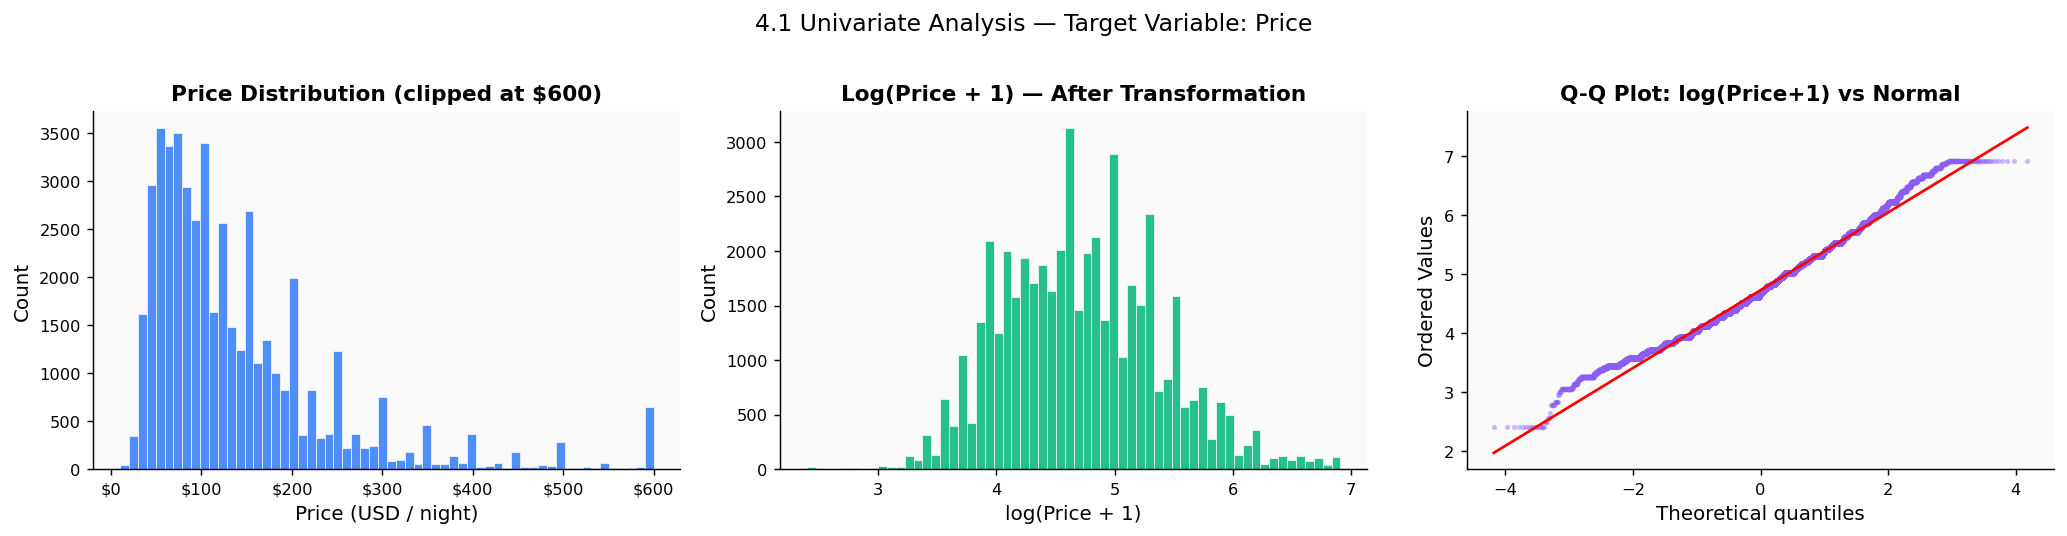

Skewness — raw price: 2.95  |  log(price+1): 0.33
→ Log-transform reduces skewness by 2.62 units.
  A skewness near 0 means the distribution is approximately normal,
  which is required by linear models and improves tree model performance.


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.1A — UNIVARIATE: TARGET VARIABLE (PRICE)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw price
axes[0].hist(df_eda['price'].clip(upper=600), bins=60,
             color='#3B82F6', edgecolor='white', linewidth=0.4, alpha=0.9)
axes[0].set_title('Price Distribution (clipped at $600)')
axes[0].set_xlabel('Price (USD / night)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Log-transformed price
log_p = np.log1p(df_eda['price'])
axes[1].hist(log_p, bins=60, color='#10B981', edgecolor='white', linewidth=0.4, alpha=0.9)
axes[1].set_title('Log(Price + 1) — After Transformation')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

# QQ-plot of log price
stats.probplot(log_p, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot: log(Price+1) vs Normal')
axes[2].get_lines()[0].set(markersize=2, alpha=0.3, color='#8B5CF6')
axes[2].get_lines()[1].set(color='red', linewidth=1.5)

plt.suptitle('4.1 Univariate Analysis — Target Variable: Price', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

raw_skew = df_eda['price'].skew()
log_skew = log_p.skew()
print(f"Skewness — raw price: {raw_skew:.2f}  |  log(price+1): {log_skew:.2f}")
print(f"→ Log-transform reduces skewness by {abs(raw_skew - log_skew):.2f} units.")
print(f"  A skewness near 0 means the distribution is approximately normal,")
print(f"  which is required by linear models and improves tree model performance.")


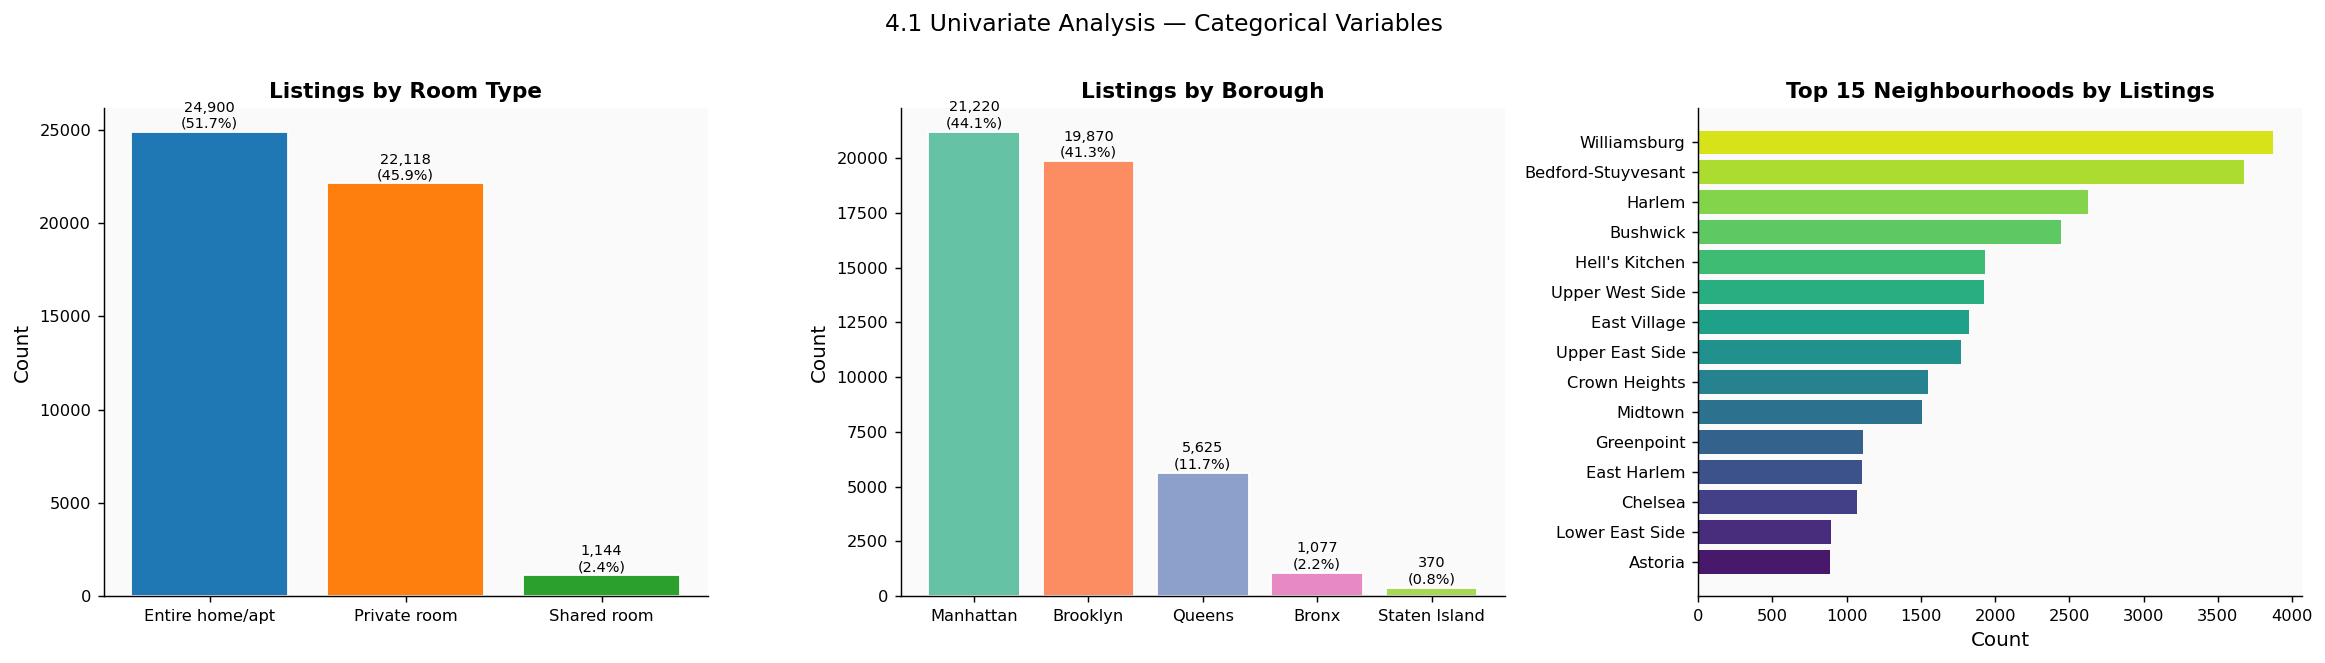

Room type breakdown:
  Entire home/apt     : 24,900 (51.7%)
  Private room        : 22,118 (45.9%)
  Shared room         : 1,144 (2.4%)


In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.1B — UNIVARIATE: CATEGORICAL FEATURES
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Room type distribution
rt_counts = df_eda['room_type'].value_counts()
bars0 = axes[0].bar(rt_counts.index, rt_counts.values,
                    color=sns.color_palette('tab10', len(rt_counts)), edgecolor='white')
axes[0].set_title('Listings by Room Type')
axes[0].set_ylabel('Count')
for bar, v in zip(bars0, rt_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df_eda)*100:.1f}%)', ha='center', fontsize=8)

# Borough distribution
ng_counts = df_eda['neighbourhood_group'].value_counts()
bars1 = axes[1].bar(ng_counts.index, ng_counts.values,
                    color=sns.color_palette('Set2', len(ng_counts)), edgecolor='white')
axes[1].set_title('Listings by Borough')
axes[1].set_ylabel('Count')
for bar, v in zip(bars1, ng_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 200,
                 f'{v:,}\n({v/len(df_eda)*100:.1f}%)', ha='center', fontsize=8)

# Top 15 neighbourhoods
top_nb = df_eda['neighbourhood'].value_counts().head(15)
axes[2].barh(top_nb.index[::-1], top_nb.values[::-1],
             color=sns.color_palette('viridis', 15))
axes[2].set_title('Top 15 Neighbourhoods by Listings')
axes[2].set_xlabel('Count')

plt.suptitle('4.1 Univariate Analysis — Categorical Variables', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Room type breakdown:")
for rt, cnt in rt_counts.items():
    print(f"  {rt:20s}: {cnt:,} ({cnt/len(df_eda)*100:.1f}%)")

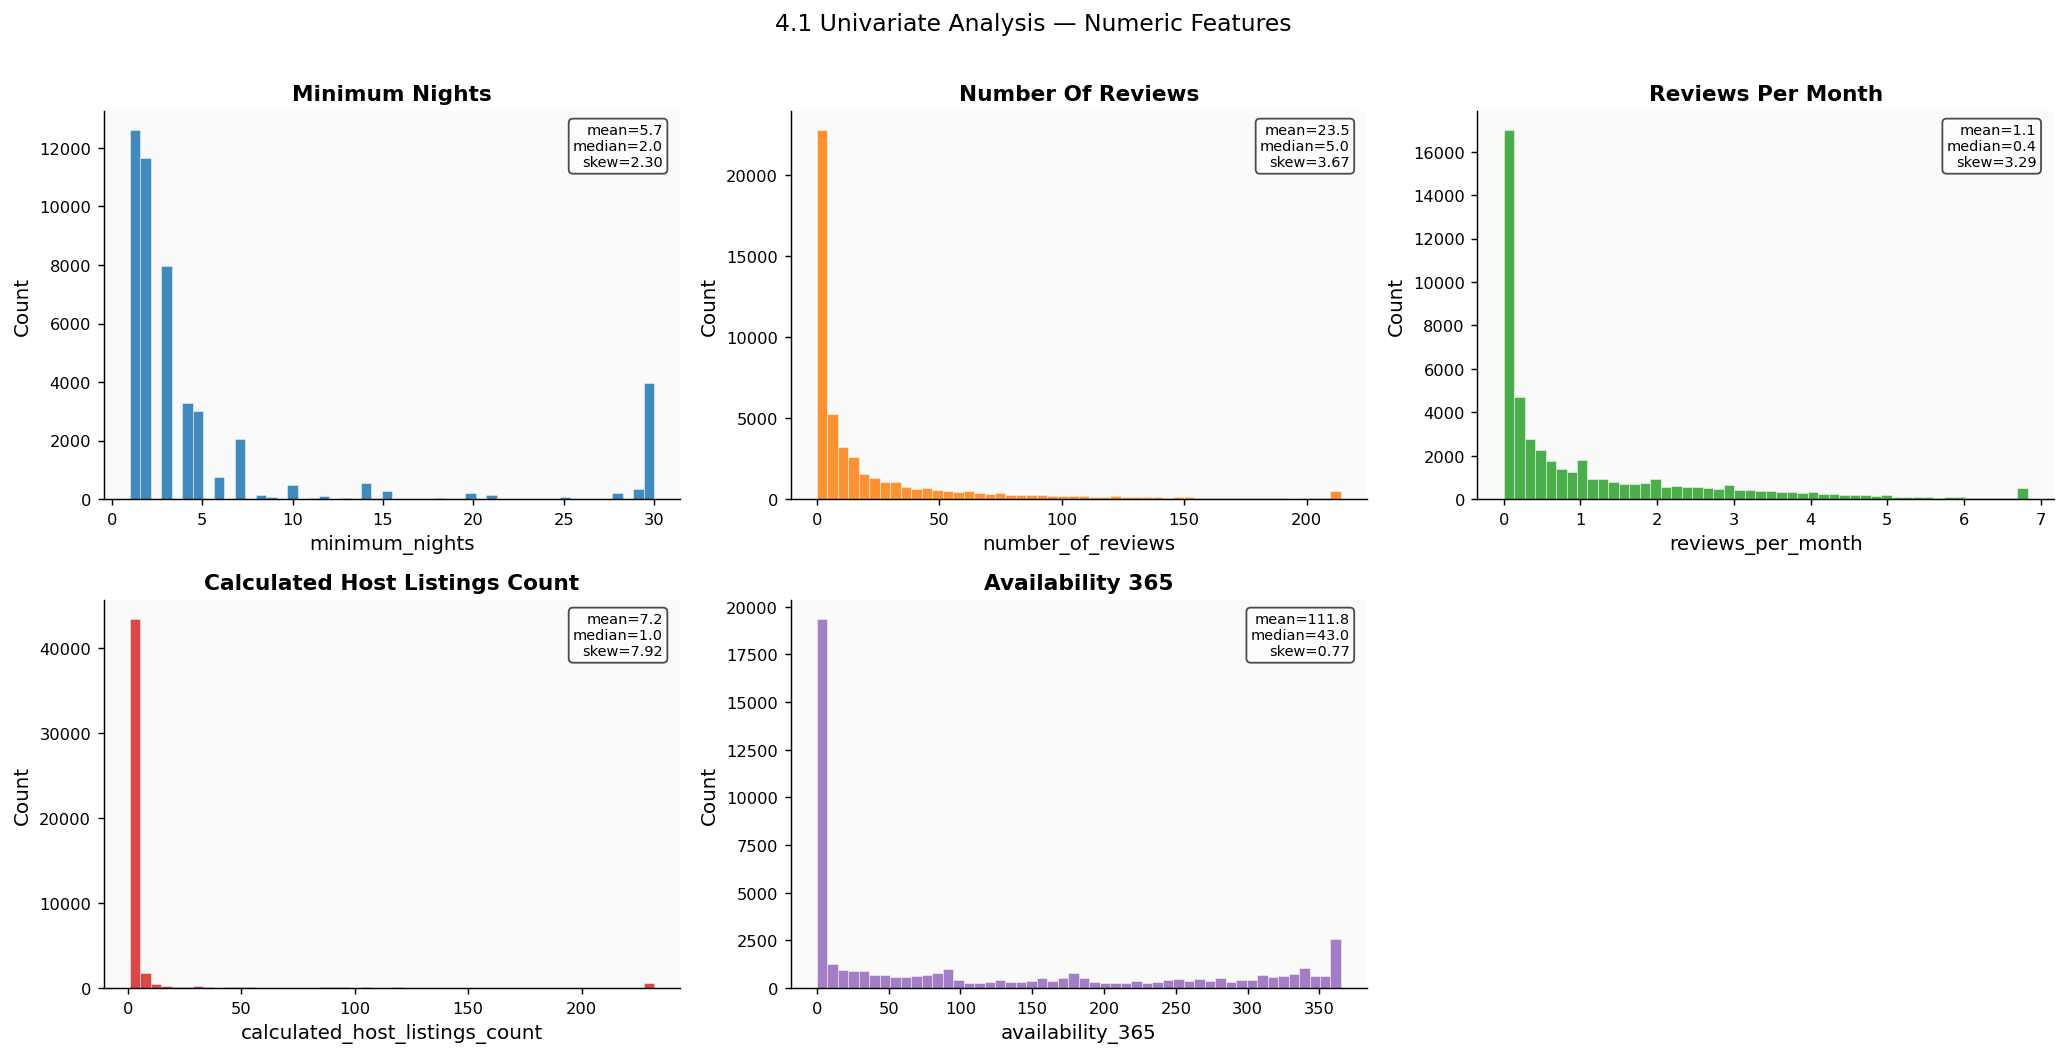

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.1C — UNIVARIATE: NUMERIC FEATURES
# ─────────────────────────────────────────────────────────────────────────────
num_cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']
num_cols = [c for c in num_cols if c in df_eda.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = sns.color_palette('tab10', len(num_cols))
for i, col in enumerate(num_cols):
    data = df_eda[col].clip(upper=df_eda[col].quantile(0.99))
    axes[i].hist(data, bins=50, color=colors[i], edgecolor='white', linewidth=0.3, alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].text(0.97, 0.97,
                 f'mean={df_eda[col].mean():.1f}\nmedian={df_eda[col].median():.1f}\nskew={df_eda[col].skew():.2f}',
                 transform=axes[i].transAxes, va='top', ha='right',
                 fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

axes[-1].set_visible(False)
plt.suptitle('4.1 Univariate Analysis — Numeric Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

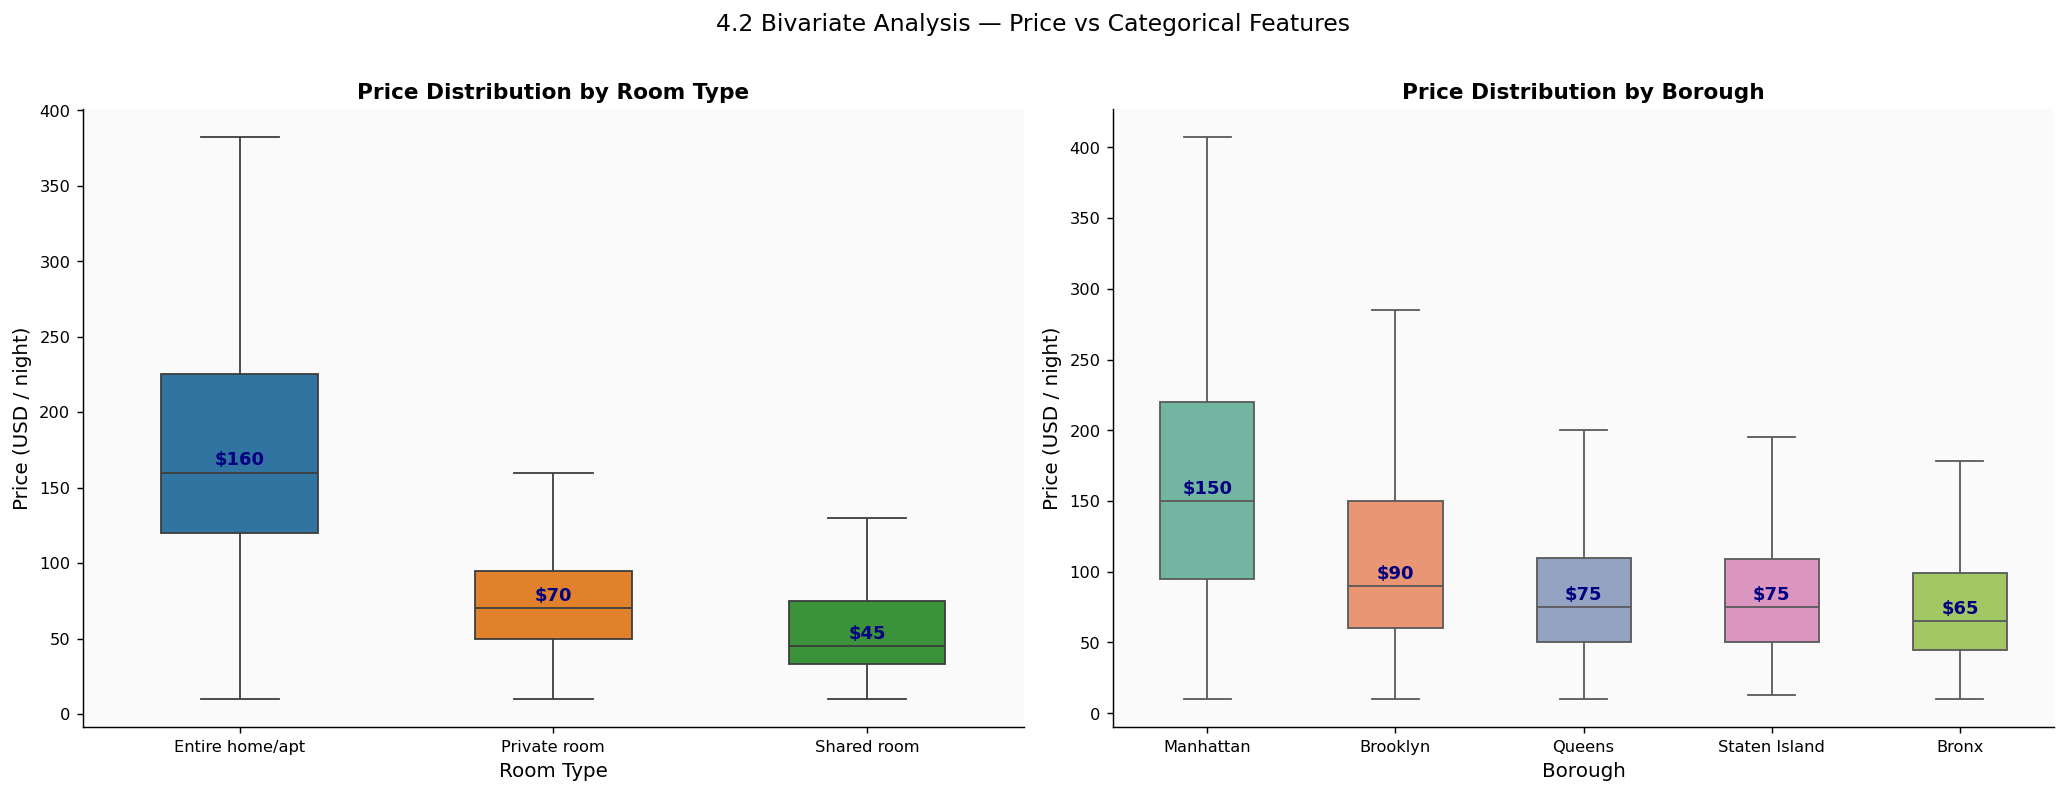

Median price by room type:
                 median   mean  count
room_type                            
Entire home/apt   160.0  195.0  24900
Private room       70.0   84.8  22118
Shared room        45.0   67.8   1144
Median price by borough:
                     median   mean  count
neighbourhood_group                      
Bronx                  65.0   85.5   1077
Brooklyn               90.0  117.9  19870
Manhattan             150.0  179.2  21220
Queens                 75.0   95.1   5625
Staten Island          75.0   98.6    370


In [36]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2A — BIVARIATE: PRICE BY CATEGORICAL FEATURES
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price by room type
order_rt = df_eda.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x='room_type', y='price', order=order_rt,
            palette='tab10', ax=axes[0], showfliers=False, width=0.5)
axes[0].set_title('Price Distribution by Room Type')
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price (USD / night)')
# Overlay median labels
for i, rt in enumerate(order_rt):
    med = df_eda[df_eda['room_type'] == rt]['price'].median()
    axes[0].text(i, med + 5, f'${med:.0f}', ha='center', fontsize=10,
                 fontweight='bold', color='navy')

# Price by borough
order_ng = df_eda.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df_eda, x='neighbourhood_group', y='price', order=order_ng,
            palette='Set2', ax=axes[1], showfliers=False, width=0.5)
axes[1].set_title('Price Distribution by Borough')
axes[1].set_xlabel('Borough')
axes[1].set_ylabel('Price (USD / night)')
for i, ng in enumerate(order_ng):
    med = df_eda[df_eda['neighbourhood_group'] == ng]['price'].median()
    axes[1].text(i, med + 5, f'${med:.0f}', ha='center', fontsize=10,
                 fontweight='bold', color='navy')

plt.suptitle('4.2 Bivariate Analysis — Price vs Categorical Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Summary table
print("Median price by room type:")
print(df_eda.groupby('room_type')['price'].agg(['median','mean','count']).round(1).to_string())
print("Median price by borough:")
print(df_eda.groupby('neighbourhood_group')['price'].agg(['median','mean','count']).round(1).to_string())


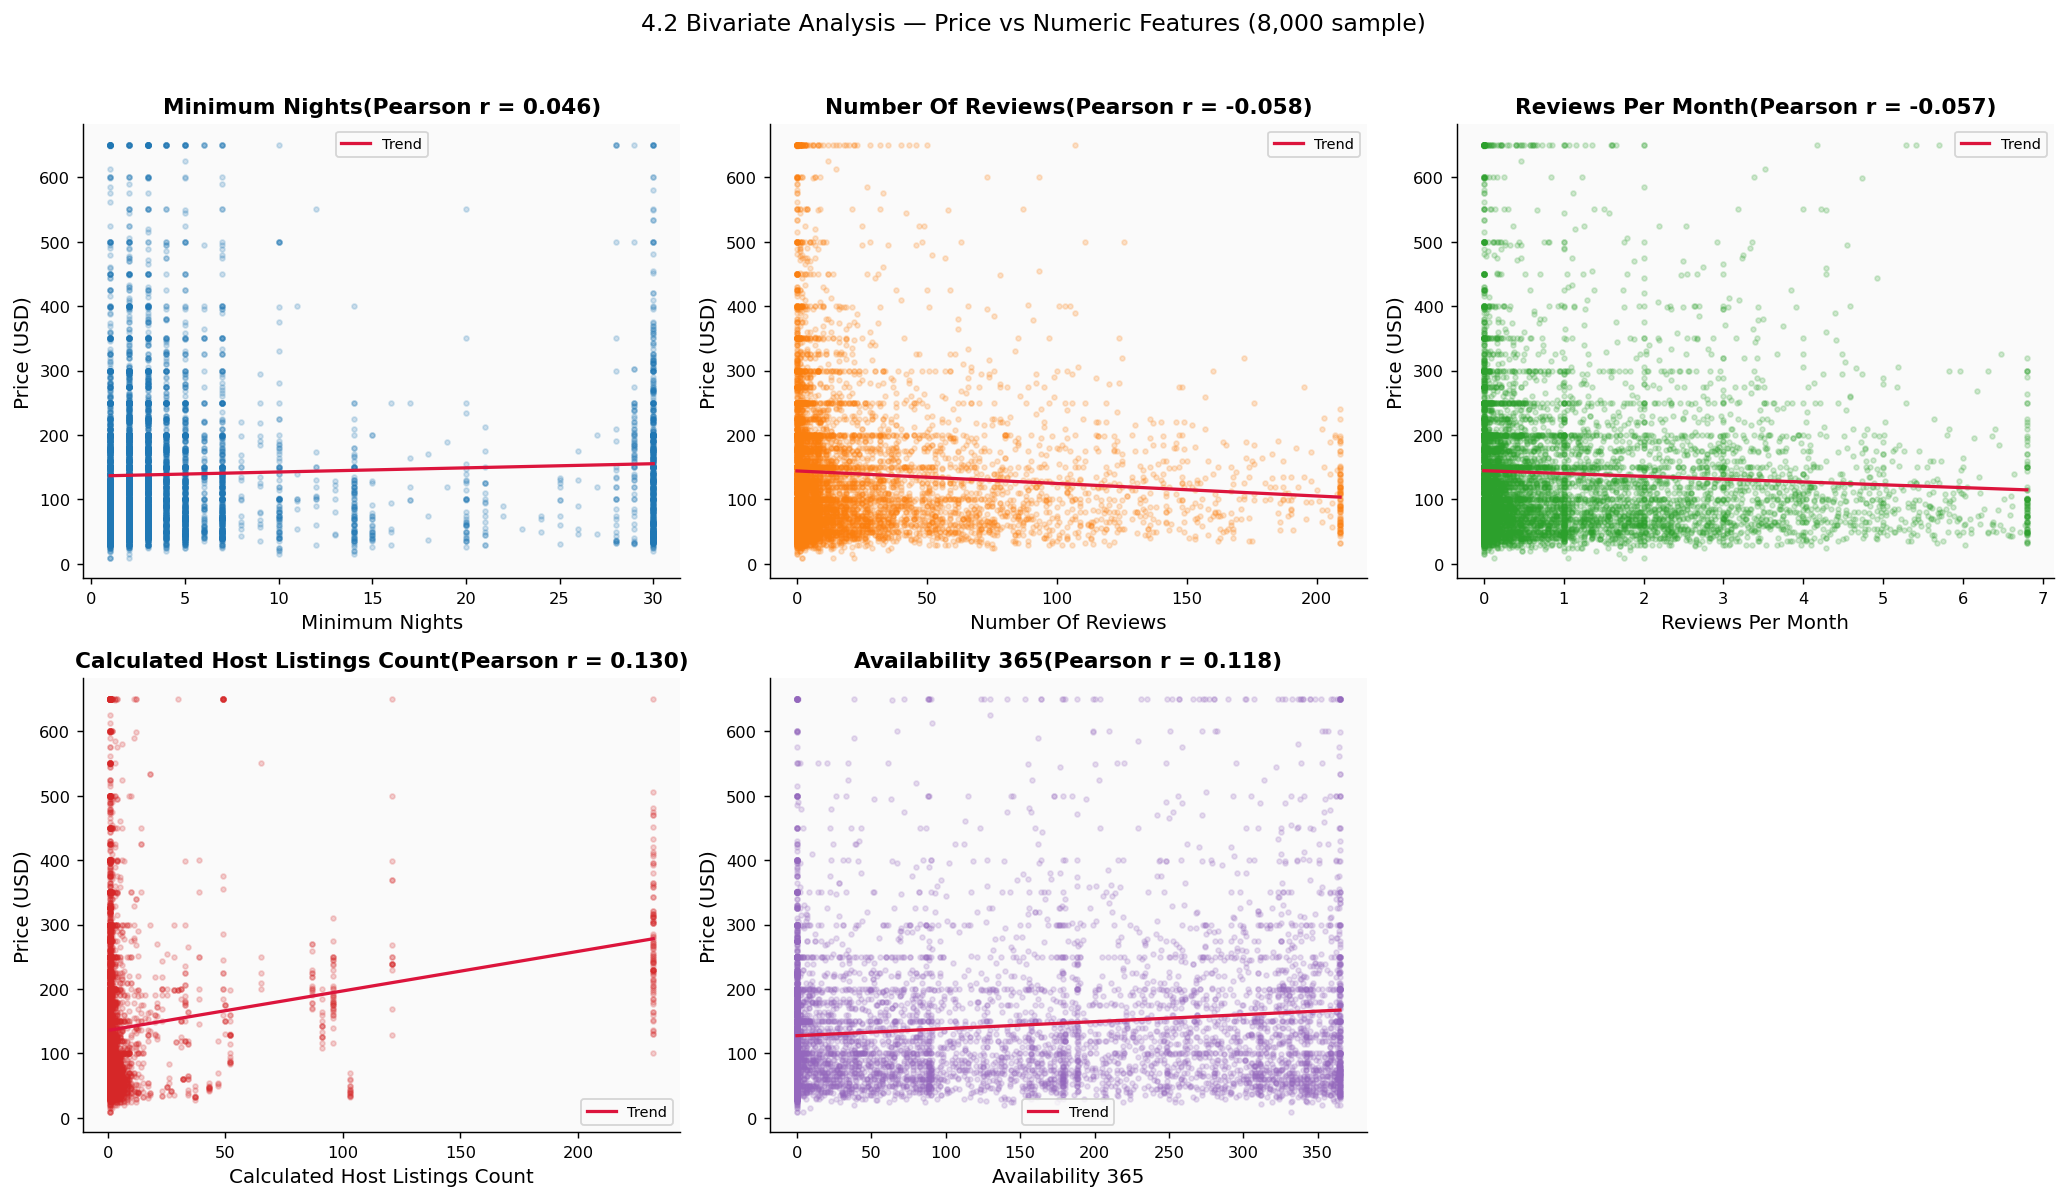

In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2B — BIVARIATE: PRICE vs NUMERIC FEATURES (SCATTER + TREND)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

num_feats = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'calculated_host_listings_count', 'availability_365']
num_feats = [c for c in num_feats if c in df_eda.columns]

colors = sns.color_palette('tab10', len(num_feats))
sample = df_eda.sample(min(8000, len(df_eda)), random_state=42)

for i, feat in enumerate(num_feats):
    x = sample[feat].clip(upper=sample[feat].quantile(0.99))
    y = sample['price'].clip(upper=sample['price'].quantile(0.99))
    axes[i].scatter(x, y, alpha=0.2, s=7, color=colors[i])

    # Trend line (linear + log scale visual)
    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    axes[i].plot(xs, np.poly1d(z)(xs), color='crimson', linewidth=1.8, label='Trend')

    corr = df_eda[[feat, 'price']].corr().iloc[0, 1]
    axes[i].set_xlabel(feat.replace('_', ' ').title())
    axes[i].set_ylabel('Price (USD)')
    axes[i].set_title(f'{feat.replace("_"," ").title()} (Pearson r = {corr:.3f})')
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('4.2 Bivariate Analysis — Price vs Numeric Features (8,000 sample)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


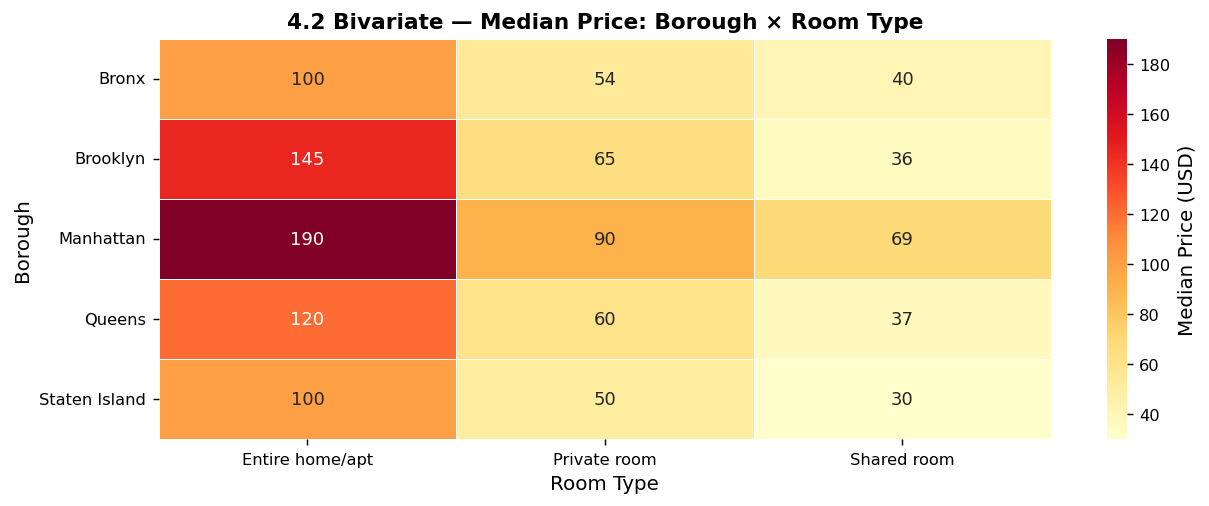

Interpretation:
  → Manhattan Entire home/apt has the highest median price.
  → Bronx Shared room has the lowest.
  → Room type has the strongest price differentiation within each borough.


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.2C — BIVARIATE: MEAN PRICE BY BOROUGH × ROOM TYPE (HEATMAP)
# ─────────────────────────────────────────────────────────────────────────────
pivot = df_eda.pivot_table(values='price', index='neighbourhood_group',
                           columns='room_type', aggfunc='median')

plt.figure(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Median Price (USD)'})
plt.title('4.2 Bivariate — Median Price: Borough × Room Type', fontsize=12)
plt.xlabel('Room Type')
plt.ylabel('Borough')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  → Manhattan Entire home/apt has the highest median price.")
print("  → Bronx Shared room has the lowest.")
print("  → Room type has the strongest price differentiation within each borough.")


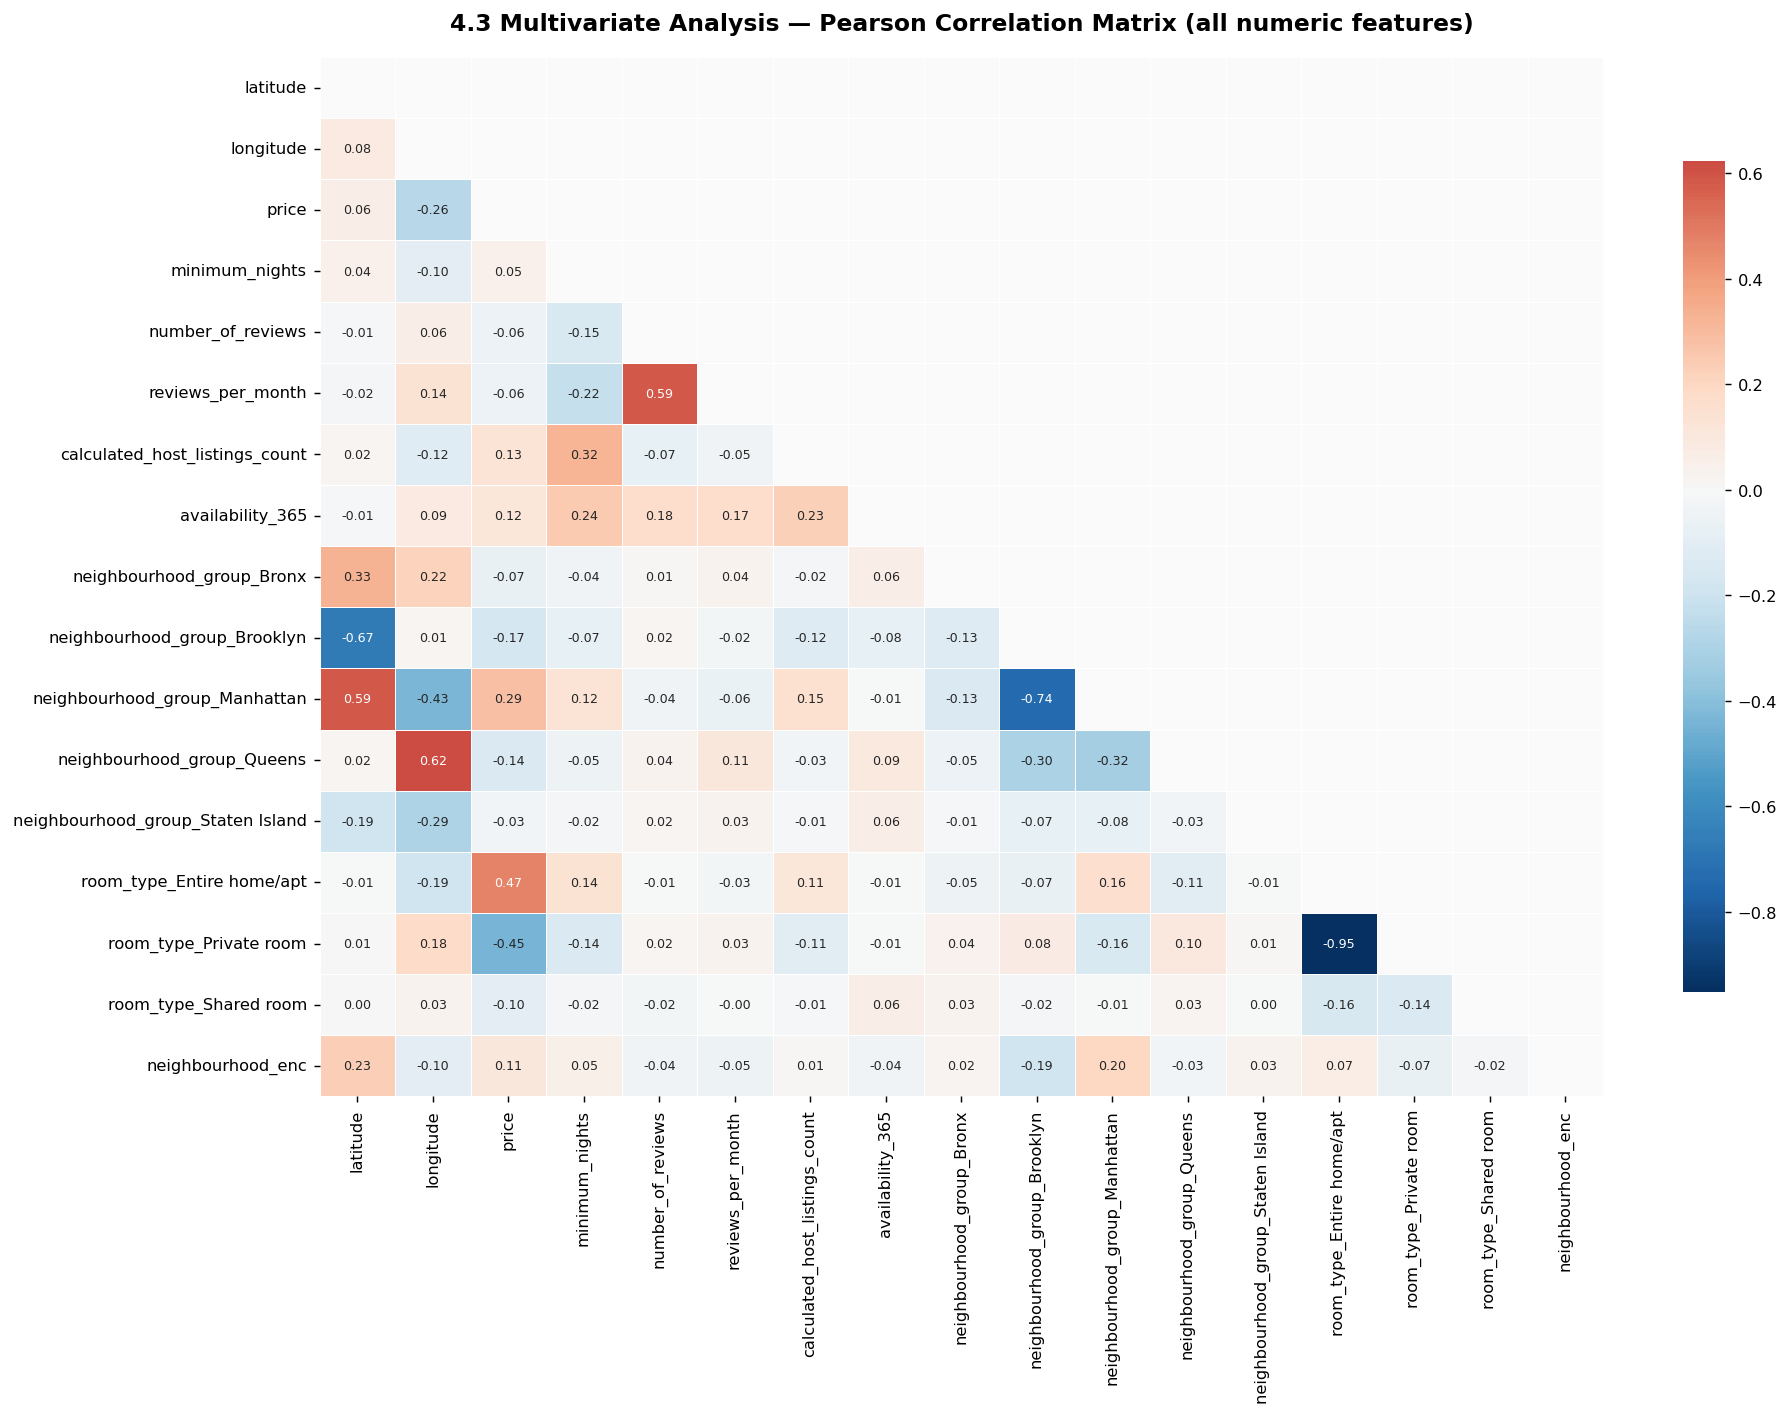

Top 10 features correlated with price (absolute Pearson r):
  room_type_Entire home/apt                    : +0.475 (+)  █████████
  room_type_Private room                       : -0.446 (-)  ████████
  neighbourhood_group_Manhattan                : +0.287 (+)  █████
  longitude                                    : -0.258 (-)  █████
  neighbourhood_group_Brooklyn                 : -0.168 (-)  ███
  neighbourhood_group_Queens                   : -0.144 (-)  ██
  calculated_host_listings_count               : +0.130 (+)  ██
  availability_365                             : +0.118 (+)  ██
  neighbourhood_enc                            : +0.112 (+)  ██
  room_type_Shared room                        : -0.098 (-)  █


In [40]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.3A — MULTIVARIATE: CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────────────────────
# Select numeric columns from the model dataframe
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 11))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.3, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
plt.title('4.3 Multivariate Analysis — Pearson Correlation Matrix (all numeric features)',
          fontsize=13, pad=15)
plt.tight_layout()
plt.show()

# Top correlations with price
price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
print("Top 10 features correlated with price (absolute Pearson r):")
for feat, r in price_corr.head(10).items():
    direction = '(+)' if r > 0 else '(-)'
    bar = '█' * int(abs(r) * 20)
    print(f"  {feat:45s}: {r:+.3f} {direction}  {bar}")


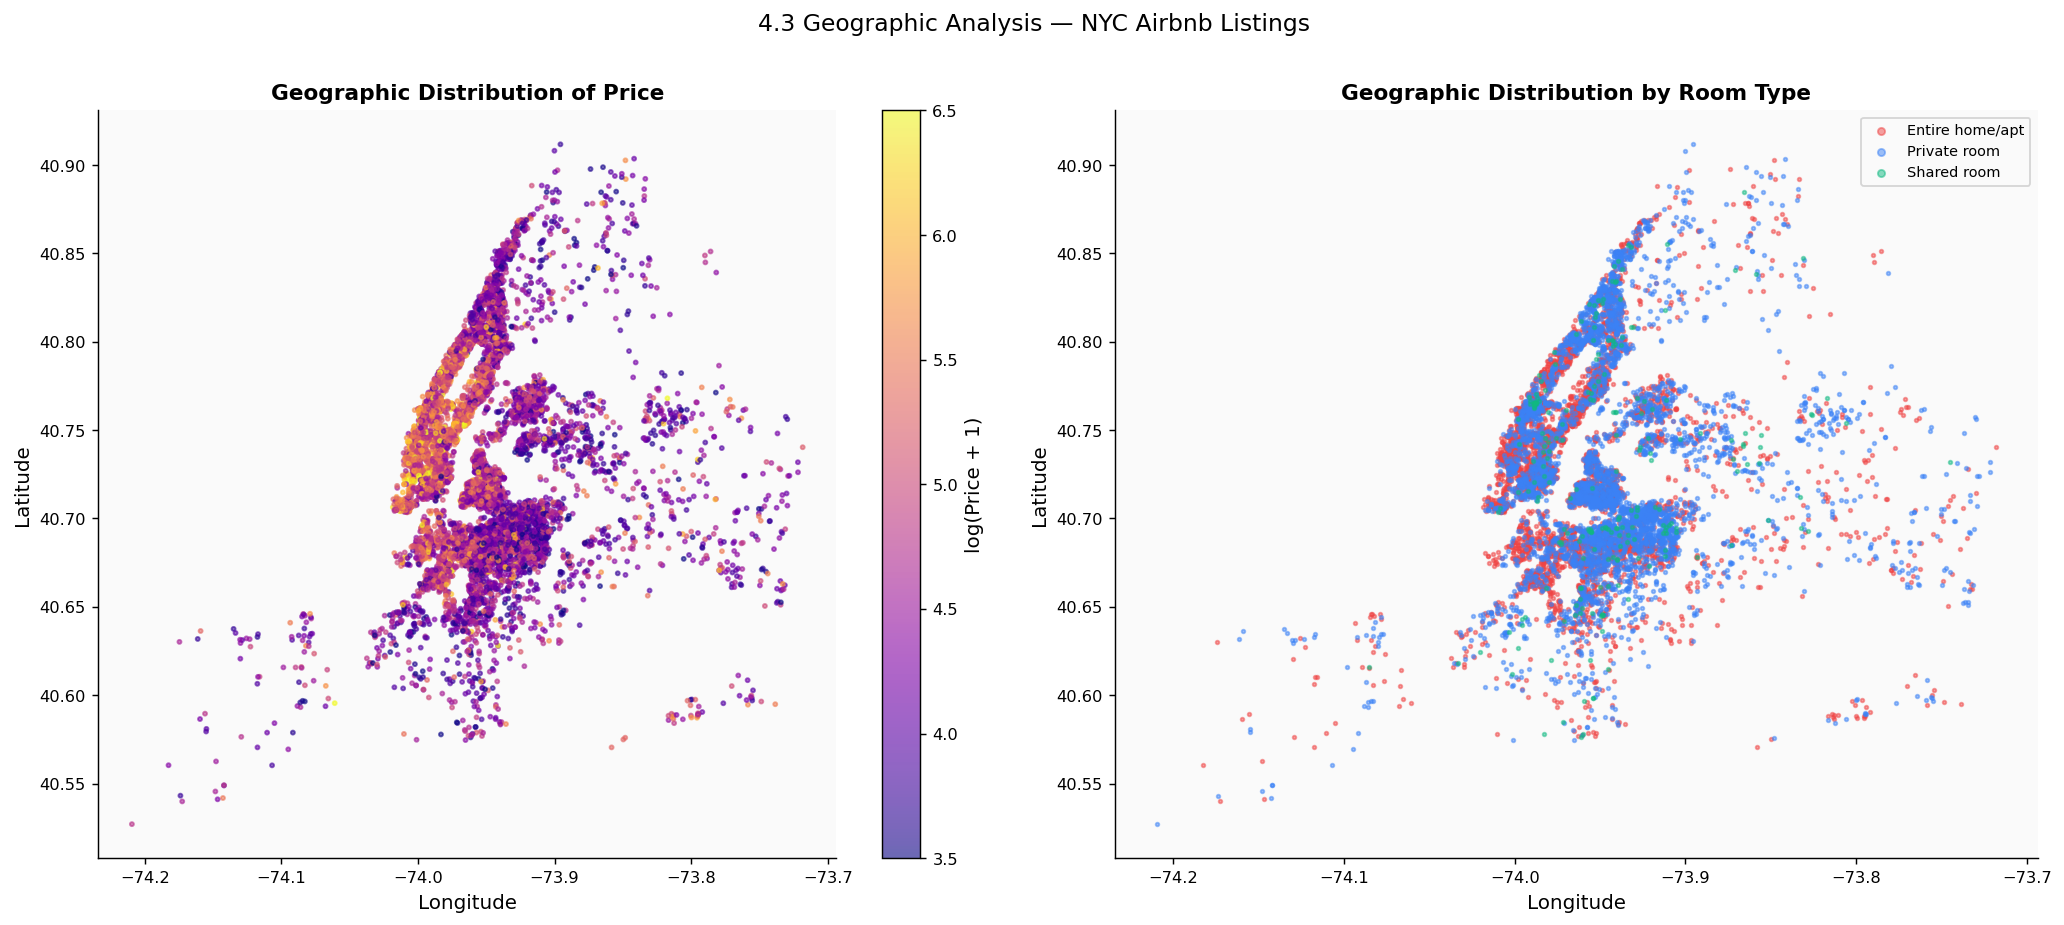

Observations:
  → High-price listings concentrate in lower Manhattan and Williamsburg.
  → Entire home/apt (red) dominates Manhattan.
  → Private rooms (blue) are distributed across all boroughs.


In [41]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 4.3B — MULTIVARIATE: GEOGRAPHIC PRICE MAP
# ─────────────────────────────────────────────────────────────────────────────
if 'latitude' in df_eda.columns and 'longitude' in df_eda.columns:
    sample_geo = df_eda.sample(min(10000, len(df_eda)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Left: price heat
    sc = axes[0].scatter(sample_geo['longitude'], sample_geo['latitude'],
                         c=np.log1p(sample_geo['price']), cmap='plasma',
                         s=5, alpha=0.6, vmin=3.5, vmax=6.5)
    cb = plt.colorbar(sc, ax=axes[0])
    cb.set_label('log(Price + 1)')
    axes[0].set_title('Geographic Distribution of Price')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    # Right: colour by room type
    rt_palette = {'Entire home/apt': '#EF4444', 'Private room': '#3B82F6',
                  'Shared room': '#10B981'}
    for rt, color in rt_palette.items():
        sub = sample_geo[sample_geo['room_type'] == rt]
        axes[1].scatter(sub['longitude'], sub['latitude'],
                        c=color, s=4, alpha=0.5, label=rt)
    axes[1].set_title('Geographic Distribution by Room Type')
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].legend(markerscale=2, fontsize=8)

    plt.suptitle('4.3 Geographic Analysis — NYC Airbnb Listings', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print("Observations:")
    print("  → High-price listings concentrate in lower Manhattan and Williamsburg.")
    print("  → Entire home/apt (red) dominates Manhattan.")
    print("  → Private rooms (blue) are distributed across all boroughs.")


## 5. Feature Engineering

Feature engineering is the process of creating new input variables from existing data that
better represent the underlying patterns the model needs to learn. Well-engineered features
often improve model performance more than choosing a more complex algorithm.

### Features Created

| Feature | Formula | Rationale |
|---|---|---|
| `log_price` | `log(price + 1)` | Normalises the right-skewed target; log-normal pricing is common in real estate |
| `log_min_nights` | `log(minimum_nights + 1)` | minimum_nights is skewed; log-scale captures diminishing effect of longer minimums |
| `reviews_per_listing` | `number_of_reviews / max(host_listings, 1)` | Normalises review count by host portfolio size — a proxy for per-listing demand |
| `availability_rate` | `availability_365 / 365` | Converts raw days to a 0–1 rate; easier for the model to generalise |
| `has_reviews` | `1 if number_of_reviews > 0 else 0` | New / inactive listings behave differently from established ones |
| `is_superhost_proxy` | `1 if calculated_host_listings_count > 3` | Hosts with many listings are likely professional operators (higher quality / price) |
| `engagement_score` | `reviews_per_month × availability_rate` | Combined demand signal: frequent reviews + high availability = popular active listing |
| `price_per_night_equiv` | `price × minimum_nights` | Total minimum spend — captures commitment barrier to booking |

### Why log-transform the target?
When we train a model on `log(price)`, the model minimises squared errors in log-space.
This means a $10 error on a $50 listing is penalised equally to a $10 error on a $500 listing —
which is a more realistic business objective than minimising absolute dollar errors (which would
cause the model to over-fit on expensive outliers).


In [43]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────────────────────

# Log-transform target
df['log_price'] = np.log1p(df['price'])

# Log-transform skewed numeric features
if 'minimum_nights' in df.columns:
    df['log_min_nights'] = np.log1p(df['minimum_nights'])

if 'number_of_reviews' in df.columns:
    df['log_num_reviews'] = np.log1p(df['number_of_reviews'])

# Reviews per listing (demand proxy)
if 'number_of_reviews' in df.columns and 'calculated_host_listings_count' in df.columns:
    df['reviews_per_listing'] = (df['number_of_reviews'] /
                                  df['calculated_host_listings_count'].clip(lower=1))

# Availability rate (0–1)
if 'availability_365' in df.columns:
    df['availability_rate'] = df['availability_365'] / 365

# Has reviews (binary)
if 'number_of_reviews' in df.columns:
    df['has_reviews'] = (df['number_of_reviews'] > 0).astype(int)

# Superhost proxy (professional operator)
if 'calculated_host_listings_count' in df.columns:
    df['is_superhost_proxy'] = (df['calculated_host_listings_count'] > 3).astype(int)

# Engagement score
if 'reviews_per_month' in df.columns and 'availability_rate' in df.columns:
    df['engagement_score'] = df['reviews_per_month'] * df['availability_rate']

# Minimum spend equivalent
if 'minimum_nights' in df.columns:
    df['min_spend_equiv'] = df['price'] * df['minimum_nights']

# Lat/lon interaction (spatial product — captures location jointly)
if 'latitude' in df.columns and 'longitude' in df.columns:
    df['lat_lon_product'] = df['latitude'] * df['longitude'].abs()

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

engineered = ['log_min_nights','log_num_reviews','reviews_per_listing',
              'availability_rate','has_reviews','is_superhost_proxy',
              'engagement_score','min_spend_equiv','lat_lon_product']
engineered = [c for c in engineered if c in df.columns]
print(f"Engineered features added ({len(engineered)}):")
for c in engineered:
    print(f"  • {c}")


Feature engineering complete.
Dataset shape: 48,162 rows × 27 columns
Engineered features added (9):
  • log_min_nights
  • log_num_reviews
  • reviews_per_listing
  • availability_rate
  • has_reviews
  • is_superhost_proxy
  • engagement_score
  • min_spend_equiv
  • lat_lon_product


## 6. Feature Selection

Feature selection removes columns that contribute noise rather than signal. Using too many
features can cause overfitting (the model memorises training data instead of generalising),
and increases both training time and memory usage.

### Methods Used

#### Mutual Information (MI)
Mutual Information measures how much knowing a feature reduces our uncertainty about the target.
Unlike Pearson correlation, MI captures **non-linear** relationships. A feature with MI = 0 is
completely uninformative; higher values indicate stronger relevance.

**Decision rule:** Features with MI score < 0.01 are dropped.

#### Random Forest Feature Importance
A quick Random Forest model is trained and its built-in `feature_importances_` attribute
(mean decrease in impurity across all trees) provides a second, tree-based importance ranking.
Features in the bottom 10th percentile by RF importance are also dropped.

#### Final Selection
The union of features selected by both methods forms the final feature set. This conservative
approach ensures we retain features that are important by at least one criterion.

> **Important note on `min_spend_equiv`:** This feature is derived from `price × minimum_nights`.
> We exclude it from the feature matrix to prevent **data leakage** — it contains the target
> variable (`price`) implicitly.


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6A — PREPARE X AND y
# ─────────────────────────────────────────────────────────────────────────────
TARGET = 'log_price'

# Columns that leak the target or are direct derivatives
LEAKAGE_COLS = {'price', 'log_price', 'min_spend_equiv'}
# Columns already encoded / represented elsewhere
# minimum_nights is retained here because we need it for feature selection;
# log_min_nights (its log transform) is also kept — Section 6D will decide
# which version(s) survive into the final feature set.
REDUNDANT_COLS = set()   # let MI + RF decide between minimum_nights & log_min_nights

DROP_FROM_X = LEAKAGE_COLS | REDUNDANT_COLS

feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c not in DROP_FROM_X]

X = df[feature_cols].copy()
y = df[TARGET].copy()

# Clean up
X.replace([np.inf, -np.inf], np.nan, inplace=True)
mask = X.notna().all(axis=1) & y.notna()
X, y = X[mask], y[mask]

# ── Train / test split BEFORE feature selection ───────────────────────────────
# Splitting here prevents the MI and RF feature selection steps (Sections 6B/6C)
# from seeing test-set labels, which would constitute data leakage.
# Section 7A reuses these same splits for model training.
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(f"Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"Target vector  : {y.shape[0]:,} values")
print(f"Feature selection will use {X_train_fs.shape[0]:,} training rows only (no leakage)")
print(f"Features entering selection:")
for i, c in enumerate(X.columns, 1):
    print(f"  {i:2d}. {c}")


Feature matrix : 48,162 rows × 23 columns
Target vector  : 48,162 values
Features entering selection:
   1. latitude
   2. longitude
   3. number_of_reviews
   4. reviews_per_month
   5. calculated_host_listings_count
   6. availability_365
   7. neighbourhood_group_Bronx
   8. neighbourhood_group_Brooklyn
   9. neighbourhood_group_Manhattan
  10. neighbourhood_group_Queens
  11. neighbourhood_group_Staten Island
  12. room_type_Entire home/apt
  13. room_type_Private room
  14. room_type_Shared room
  15. neighbourhood_enc
  16. log_min_nights
  17. log_num_reviews
  18. reviews_per_listing
  19. availability_rate
  20. has_reviews
  21. is_superhost_proxy
  22. engagement_score
  23. lat_lon_product


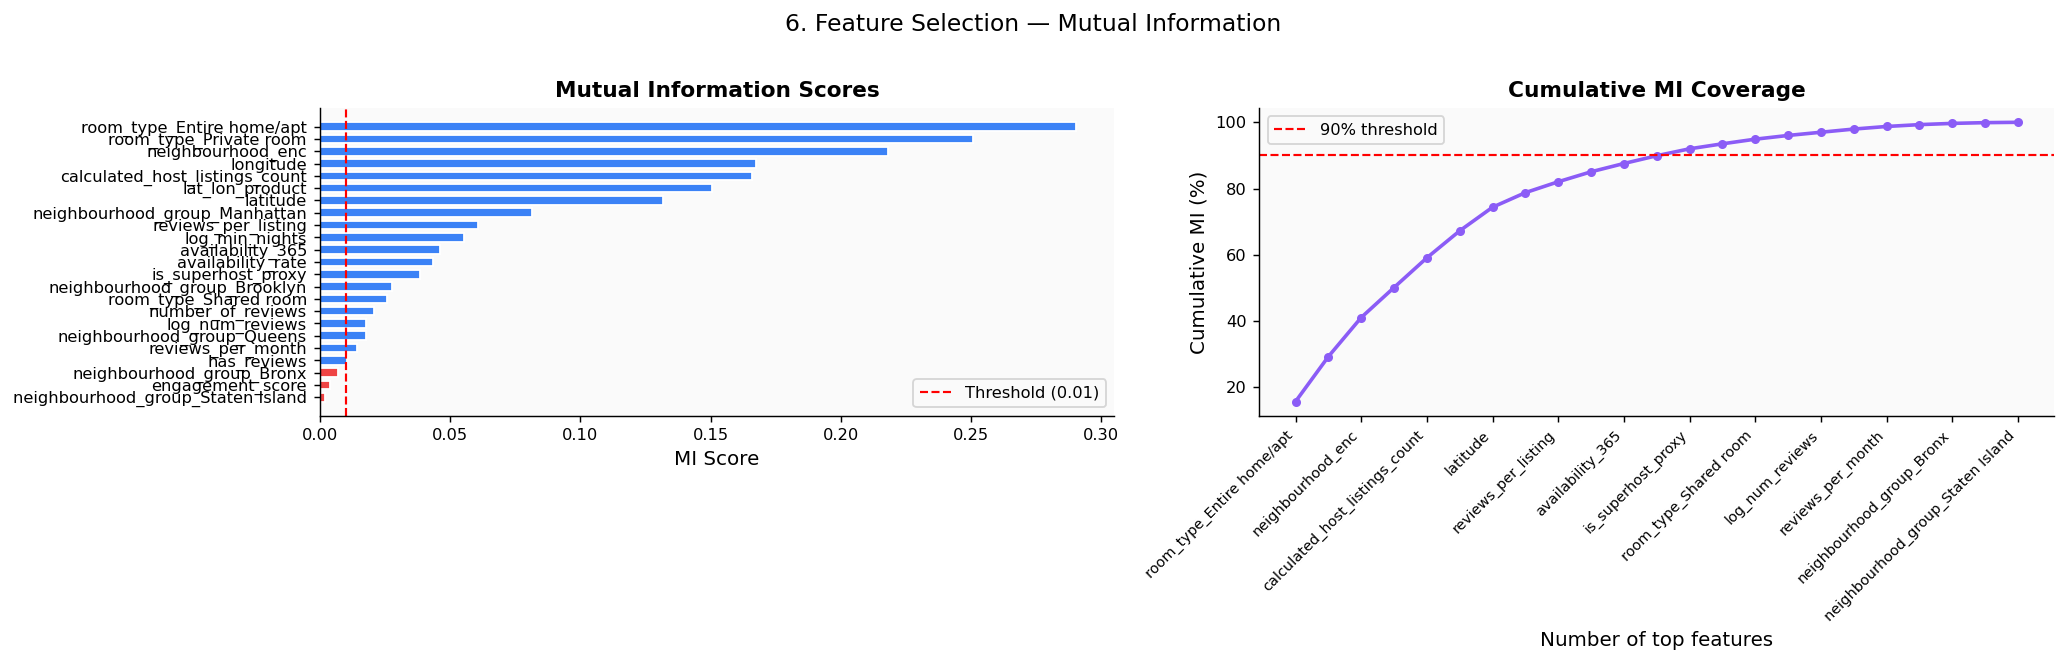

Features with MI ≥ 0.01: 20  → KEPT
Features with MI <  0.01: 3  → DROPPED
  Dropped: ['neighbourhood_group_Bronx', 'engagement_score', 'neighbourhood_group_Staten Island']


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6B — MUTUAL INFORMATION SCORES  (fit on training data only)
# ─────────────────────────────────────────────────────────────────────────────
# FIX: previously MI was computed on the full dataset (including test rows),
# which is a form of data leakage. Now it is fit on X_train_fs only.
mi_scores  = mutual_info_regression(X_train_fs, y_train_fs, random_state=RANDOM_STATE)
mi_series  = pd.Series(mi_scores, index=X_train_fs.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors_mi = ['#EF4444' if v < 0.01 else '#3B82F6' for v in mi_series.values]
axes[0].barh(mi_series.index[::-1], mi_series.values[::-1],
             color=colors_mi[::-1], edgecolor='white', height=0.7)
axes[0].axvline(0.01, color='red', linestyle='--', linewidth=1.2, label='Threshold (0.01)')
axes[0].set_title('Mutual Information Scores (training data only)')
axes[0].set_xlabel('MI Score')
axes[0].legend()

# Cumulative MI
cumulative = mi_series.cumsum() / mi_series.sum() * 100
axes[1].plot(range(len(cumulative)), cumulative.values, marker='o', markersize=4,
             color='#8B5CF6', linewidth=2)
axes[1].axhline(90, color='red', linestyle='--', linewidth=1.2, label='90% threshold')
axes[1].set_title('Cumulative MI Coverage')
axes[1].set_xlabel('Number of top features')
axes[1].set_ylabel('Cumulative MI (%)')
axes[1].set_xticks(range(0, len(cumulative), 2))
axes[1].set_xticklabels(mi_series.index[:len(cumulative):2], rotation=45, ha='right', fontsize=8)
axes[1].legend()

plt.suptitle('6. Feature Selection — Mutual Information', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

MI_THRESHOLD = 0.01
mi_selected  = mi_series[mi_series >= MI_THRESHOLD].index.tolist()
mi_dropped   = mi_series[mi_series  < MI_THRESHOLD].index.tolist()
print(f"Features with MI ≥ {MI_THRESHOLD}: {len(mi_selected)}  → KEPT")
print(f"Features with MI <  {MI_THRESHOLD}: {len(mi_dropped)}  → DROPPED")
if mi_dropped:
    print(f"  Dropped: {mi_dropped}")


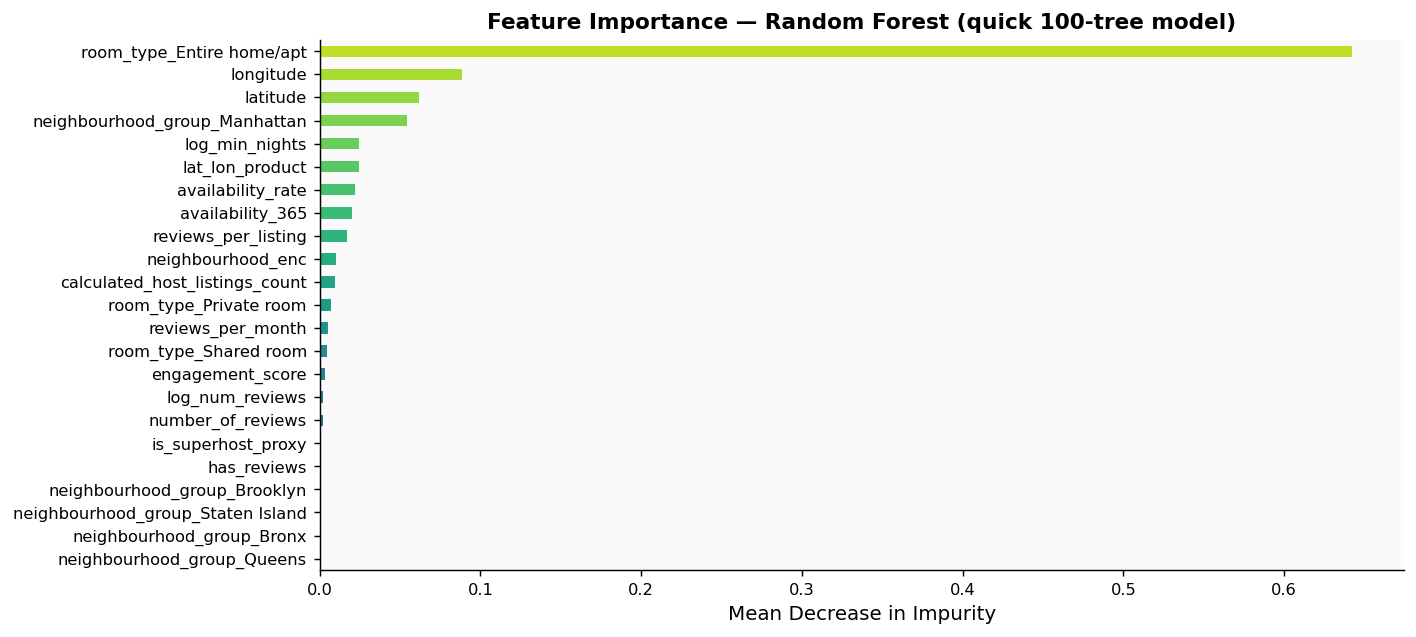

RF importance threshold (10th pct): 0.00006
Features retained by RF: 20


In [46]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6C — RANDOM FOREST IMPORTANCE  (fit on training data only)
# ─────────────────────────────────────────────────────────────────────────────
# FIX: previously the quick RF was fit on the full dataset. Now it is fit on
# X_train_fs only to keep feature selection entirely within the training set.
rf_sel = RandomForestRegressor(n_estimators=100, max_depth=8,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train_fs, y_train_fs)

fi_series = pd.Series(rf_sel.feature_importances_, index=X_train_fs.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 5))
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(fi_series)))
fi_series.sort_values().plot(kind='barh', color=colors_fi)
plt.title('Feature Importance — Random Forest (quick 100-tree model, training data only)', fontsize=12)
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

RF_THRESHOLD  = fi_series.quantile(0.10)   # drop bottom 10%
rf_selected   = fi_series[fi_series >= RF_THRESHOLD].index.tolist()
print(f"RF importance threshold (10th pct): {RF_THRESHOLD:.5f}")
print(f"Features retained by RF: {len(rf_selected)}")


In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6D — FINAL FEATURE SET (union of MI + RF)
# ─────────────────────────────────────────────────────────────────────────────
SELECTED_FEATURES = sorted(set(mi_selected) | set(rf_selected))

X_sel = X[SELECTED_FEATURES].copy()
print(f"Final feature count : {len(SELECTED_FEATURES)}")
print(f"Final feature matrix: {X_sel.shape[0]:,} rows × {X_sel.shape[1]} columns")
print(f"Selected features:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    mi_val = mi_series.get(f, 0)
    rf_val = fi_series.get(f, 0)
    print(f"  {i:2d}. {f:45s}  MI={mi_val:.4f}  RF={rf_val:.4f}")


Final feature count : 21
Final feature matrix: 48,162 rows × 21 columns
Selected features:
   1. availability_365                               MI=0.0463  RF=0.0201
   2. availability_rate                              MI=0.0434  RF=0.0223
   3. calculated_host_listings_count                 MI=0.1658  RF=0.0094
   4. engagement_score                               MI=0.0041  RF=0.0031
   5. has_reviews                                    MI=0.0103  RF=0.0001
   6. is_superhost_proxy                             MI=0.0386  RF=0.0007
   7. lat_lon_product                                MI=0.1505  RF=0.0244
   8. latitude                                       MI=0.1316  RF=0.0621
   9. log_min_nights                                 MI=0.0556  RF=0.0244
  10. log_num_reviews                                MI=0.0179  RF=0.0021
  11. longitude                                      MI=0.1673  RF=0.0883
  12. neighbourhood_enc                              MI=0.2180  RF=0.0104
  13. neighbourhood_g

## 7. Model Training & Evaluation

### Train / Test Split Strategy
We use an **80/20 random split** with a fixed random seed (42) to ensure reproducibility.
The test set is held out entirely during training — it is only used for final evaluation.

### Cross-Validation
Each model is evaluated using **5-fold cross-validation** on the training set. This provides
a more reliable estimate of out-of-sample performance than a single validation split, and
helps detect overfitting (a large gap between CV score and test score signals overfitting).

### Models Evaluated

| Model | Type | Key Hyperparameters |
|---|---|---|
| Linear Regression | Linear | — (baseline) |
| Ridge | Linear + L2 regularisation | α = 1.0 |
| Lasso | Linear + L1 regularisation | α = 0.01 |
| ElasticNet | Linear + L1 + L2 | α = 0.01, l1_ratio = 0.5 |
| Decision Tree | Non-linear, single tree | max_depth = 10 |
| Random Forest | Ensemble (bagging) | 300 trees, max_depth = 15 |
| Extra Trees | Ensemble (extreme randomisation) | 300 trees |
| Gradient Boosting | Ensemble (boosting) | 300 trees, lr = 0.05 |
| XGBoost | Gradient boosting (optimised) | 500 trees, lr = 0.05 |
| LightGBM | Gradient boosting (leaf-wise) | 500 trees, lr = 0.05 |

### Evaluation Metrics

| Metric | Description | Better when |
|---|---|---|
| **R²** | Proportion of variance explained | Higher (max 1.0) |
| **MAE (log)** | Mean absolute error in log-price space | Lower |
| **RMSE (log)** | Root mean squared error in log-price space | Lower |
| **MAE ($)** | Mean absolute dollar error (original scale) | Lower |
| **MAPE (%)** | Mean absolute percentage error | Lower |

> All primary metrics are on the **log-transformed price** scale. Dollar-scale metrics are
> computed by inverting the log transform: `pred_price = exp(pred_log_price) − 1`.


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7A — TRAIN / TEST SPLIT & SCALING
# ─────────────────────────────────────────────────────────────────────────────
# We reuse the split already created in Section 6A (X_train_fs / X_test_fs)
# so that feature selection and model training use identical partitions.

# ── Re-apply target encoding using ONLY training rows (no leakage) ───────────
# In Section 3D we used a global map for convenience during EDA/feature-selection.
# Here we rebuild the map from training rows only and re-encode neighbourhood_enc.
if 'neighbourhood_enc' in X_train_fs.columns:
    # Recover the original neighbourhood column from df_eda
    train_idx = X_train_fs.index
    test_idx  = X_test_fs.index

    # Recompute mean log-price per neighbourhood from training rows
    train_nb_prices = df_eda.loc[train_idx, 'neighbourhood'] if 'neighbourhood' in df_eda.columns else None

    if train_nb_prices is not None:
        train_log_price = np.log1p(df_eda.loc[train_idx, 'price'])
        nb_target_map_train = (
            pd.DataFrame({'nb': train_nb_prices, 'lp': train_log_price})
              .groupby('nb')['lp'].mean()
        )
        global_mean_lp = train_log_price.mean()

        # Apply to both train and test (test uses training map — no leakage)
        X_train_fs = X_train_fs.copy()
        X_test_fs  = X_test_fs.copy()
        X_train_fs['neighbourhood_enc'] = (
            df_eda.loc[train_idx, 'neighbourhood']
              .map(nb_target_map_train).fillna(global_mean_lp).values
        )
        X_test_fs['neighbourhood_enc']  = (
            df_eda.loc[test_idx,  'neighbourhood']
              .map(nb_target_map_train).fillna(global_mean_lp).values
        )
        print("✅ neighbourhood_enc re-encoded using training-only target map (no leakage).")

# Subset to selected features
X_train = X_train_fs[SELECTED_FEATURES].copy()
X_test  = X_test_fs[SELECTED_FEATURES].copy()
y_train = y_train_fs.copy()
y_test  = y_test_fs.copy()

print(f"Training samples : {X_train.shape[0]:,}  ({100-TEST_SIZE*100:.0f}%)")
print(f"Test samples     : {X_test.shape[0]:,}  ({TEST_SIZE*100:.0f}%)")
print(f"Features         : {X_train.shape[1]}")

# RobustScaler is more resistant to outliers than StandardScaler
scaler = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Training samples : 38,529  (80%)
Test samples     : 9,633  (20%)
Features         : 21


In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7B — DEFINE ALL MODELS
# ─────────────────────────────────────────────────────────────────────────────
LINEAR_MODELS = {'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet'}

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet'        : ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, min_samples_leaf=20,
                                                 random_state=RANDOM_STATE),
    'Extra Trees'       : ExtraTreesRegressor(n_estimators=300, max_depth=15,
                                               min_samples_leaf=10,
                                               random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest'     : RandomForestRegressor(n_estimators=300, max_depth=15,
                                                 min_samples_leaf=10,
                                                 random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                     max_depth=5, subsample=0.8,
                                                     random_state=RANDOM_STATE),
}
if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(n_estimators=500, learning_rate=0.05,
                                      max_depth=6, subsample=0.8,
                                      colsample_bytree=0.8, reg_alpha=0.1,
                                      reg_lambda=1.0, random_state=RANDOM_STATE,
                                      eval_metric='rmse', verbosity=0, n_jobs=-1)
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                                        max_depth=6, subsample=0.8,
                                        colsample_bytree=0.8, reg_alpha=0.1,
                                        reg_lambda=1.0, random_state=RANDOM_STATE,
                                        verbose=-1, n_jobs=-1)

print(f"Models to evaluate: {len(models)}")
for name in models:
    print(f"  • {name}")


Models to evaluate: 9
  • Linear Regression
  • Ridge
  • Lasso
  • ElasticNet
  • Decision Tree
  • Extra Trees
  • Random Forest
  • Gradient Boosting
  • XGBoost


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7C — TRAIN, CROSS-VALIDATE, AND EVALUATE ALL MODELS
# ─────────────────────────────────────────────────────────────────────────────
results    = []
kf         = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fitted     = {}   # store fitted models

print(f"{'Model':25s} {'CV R² mean':>12} {'CV R² std':>10} {'Test R²':>10} "
      f"{'MAE(log)':>10} {'RMSE(log)':>11} {'MAE($)':>9} {'MAPE%':>8}")
print("-" * 105)

for name, model in models.items():
    is_linear = name in LINEAR_MODELS
    Xtr = X_train_sc if is_linear else X_train.values
    Xte = X_test_sc  if is_linear else X_test.values

    # Cross-validation
    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf,
                                 scoring='r2', n_jobs=-1)

    # Fit on full training set
    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    # Predict
    y_pred_log = model.predict(Xte)
    y_pred_usd = np.expm1(y_pred_log).clip(0)
    y_test_usd = np.expm1(y_test)

    # Metrics
    r2   = r2_score(y_test, y_pred_log)
    mae  = mean_absolute_error(y_test, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
    mae_usd  = mean_absolute_error(y_test_usd, y_pred_usd)
    mape = mean_absolute_percentage_error(y_test_usd, y_pred_usd) * 100

    results.append({
        'Model'       : name,
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)' : round(cv_scores.std(),  4),
        'Test R²'     : round(r2,  4),
        'MAE (log)'   : round(mae, 4),
        'RMSE (log)'  : round(rmse,4),
        'MAE ($)'     : round(mae_usd, 2),
        'MAPE (%)'    : round(mape, 2),
        'Train Time(s)': round(train_time, 2),
    })
    fitted[name] = model

    print(f"{name:25s} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f} "
          f"{r2:>10.4f} {mae:>10.4f} {rmse:>11.4f} {mae_usd:>9.2f} {mape:>8.2f}%")

results_df = (pd.DataFrame(results)
              .sort_values('Test R²', ascending=False)
              .reset_index(drop=True))

print("\n\n── Full Results Table ──────────────────────────────────────────────────────")
display(results_df.style
        .background_gradient(cmap='Greens',  subset=['Test R²', 'CV R² (mean)'])
        .background_gradient(cmap='Reds_r',  subset=['MAPE (%)', 'MAE ($)'])
        .format({'CV R² (mean)': '{:.4f}', 'CV R² (std)': '{:.4f}',
                 'Test R²': '{:.4f}', 'MAE (log)': '{:.4f}',
                 'RMSE (log)': '{:.4f}', 'MAE ($)': '{:.2f}',
                 'MAPE (%)': '{:.2f}', 'Train Time(s)': '{:.2f}'})
        .set_properties(**{'font-size': '11px'}))


Model                       CV R² mean  CV R² std    Test R²   MAE(log)   RMSE(log)    MAE($)    MAPE%
---------------------------------------------------------------------------------------------------------
Linear Regression               0.5382     0.0034     0.5478     0.3379      0.4461     50.56    35.64%
Ridge                           0.5318     0.0032     0.5400     0.3415      0.4500     51.13    36.16%
Lasso                           0.5114     0.0020     0.5185     0.3482      0.4603     51.67    36.91%
ElasticNet                      0.5213     0.0025     0.5284     0.3451      0.4556     51.39    36.54%
Decision Tree                   0.5828     0.0037     0.5968     0.3167      0.4213     48.26    33.55%
Extra Trees                     0.6282     0.0055     0.6368     0.2979      0.3998     45.45    31.25%
Random Forest                   0.6300     0.0054     0.6396     0.2974      0.3983     45.38    31.21%
Gradient Boosting               0.6325     0.0051     0.6414   

,Model,CV R² (mean),CV R² (std),Test R²,MAE (log),RMSE (log),MAE ($),MAPE (%),Train Time(s)
0,XGBoost,0.6398,0.0061,0.6462,0.2943,0.3946,44.93,30.87,3.13
1,Gradient Boosting,0.6325,0.0051,0.6414,0.2979,0.3973,45.58,31.16,49.59
2,Random Forest,0.6300,0.0054,0.6396,0.2974,0.3983,45.38,31.21,19.44
3,Extra Trees,0.6282,0.0055,0.6368,0.2979,0.3998,45.45,31.25,9.12
4,Decision Tree,0.5828,0.0037,0.5968,0.3167,0.4213,48.26,33.55,0.45
5,Linear Regression,0.5382,0.0034,0.5478,0.3379,0.4461,50.56,35.64,0.04
6,Ridge,0.5318,0.0032,0.5400,0.3415,0.4500,51.13,36.16,0.01
7,ElasticNet,0.5213,0.0025,0.5284,0.3451,0.4556,51.39,36.54,0.36
8,Lasso,0.5114,0.0020,0.5185,0.3482,0.4603,51.67,36.91,0.06


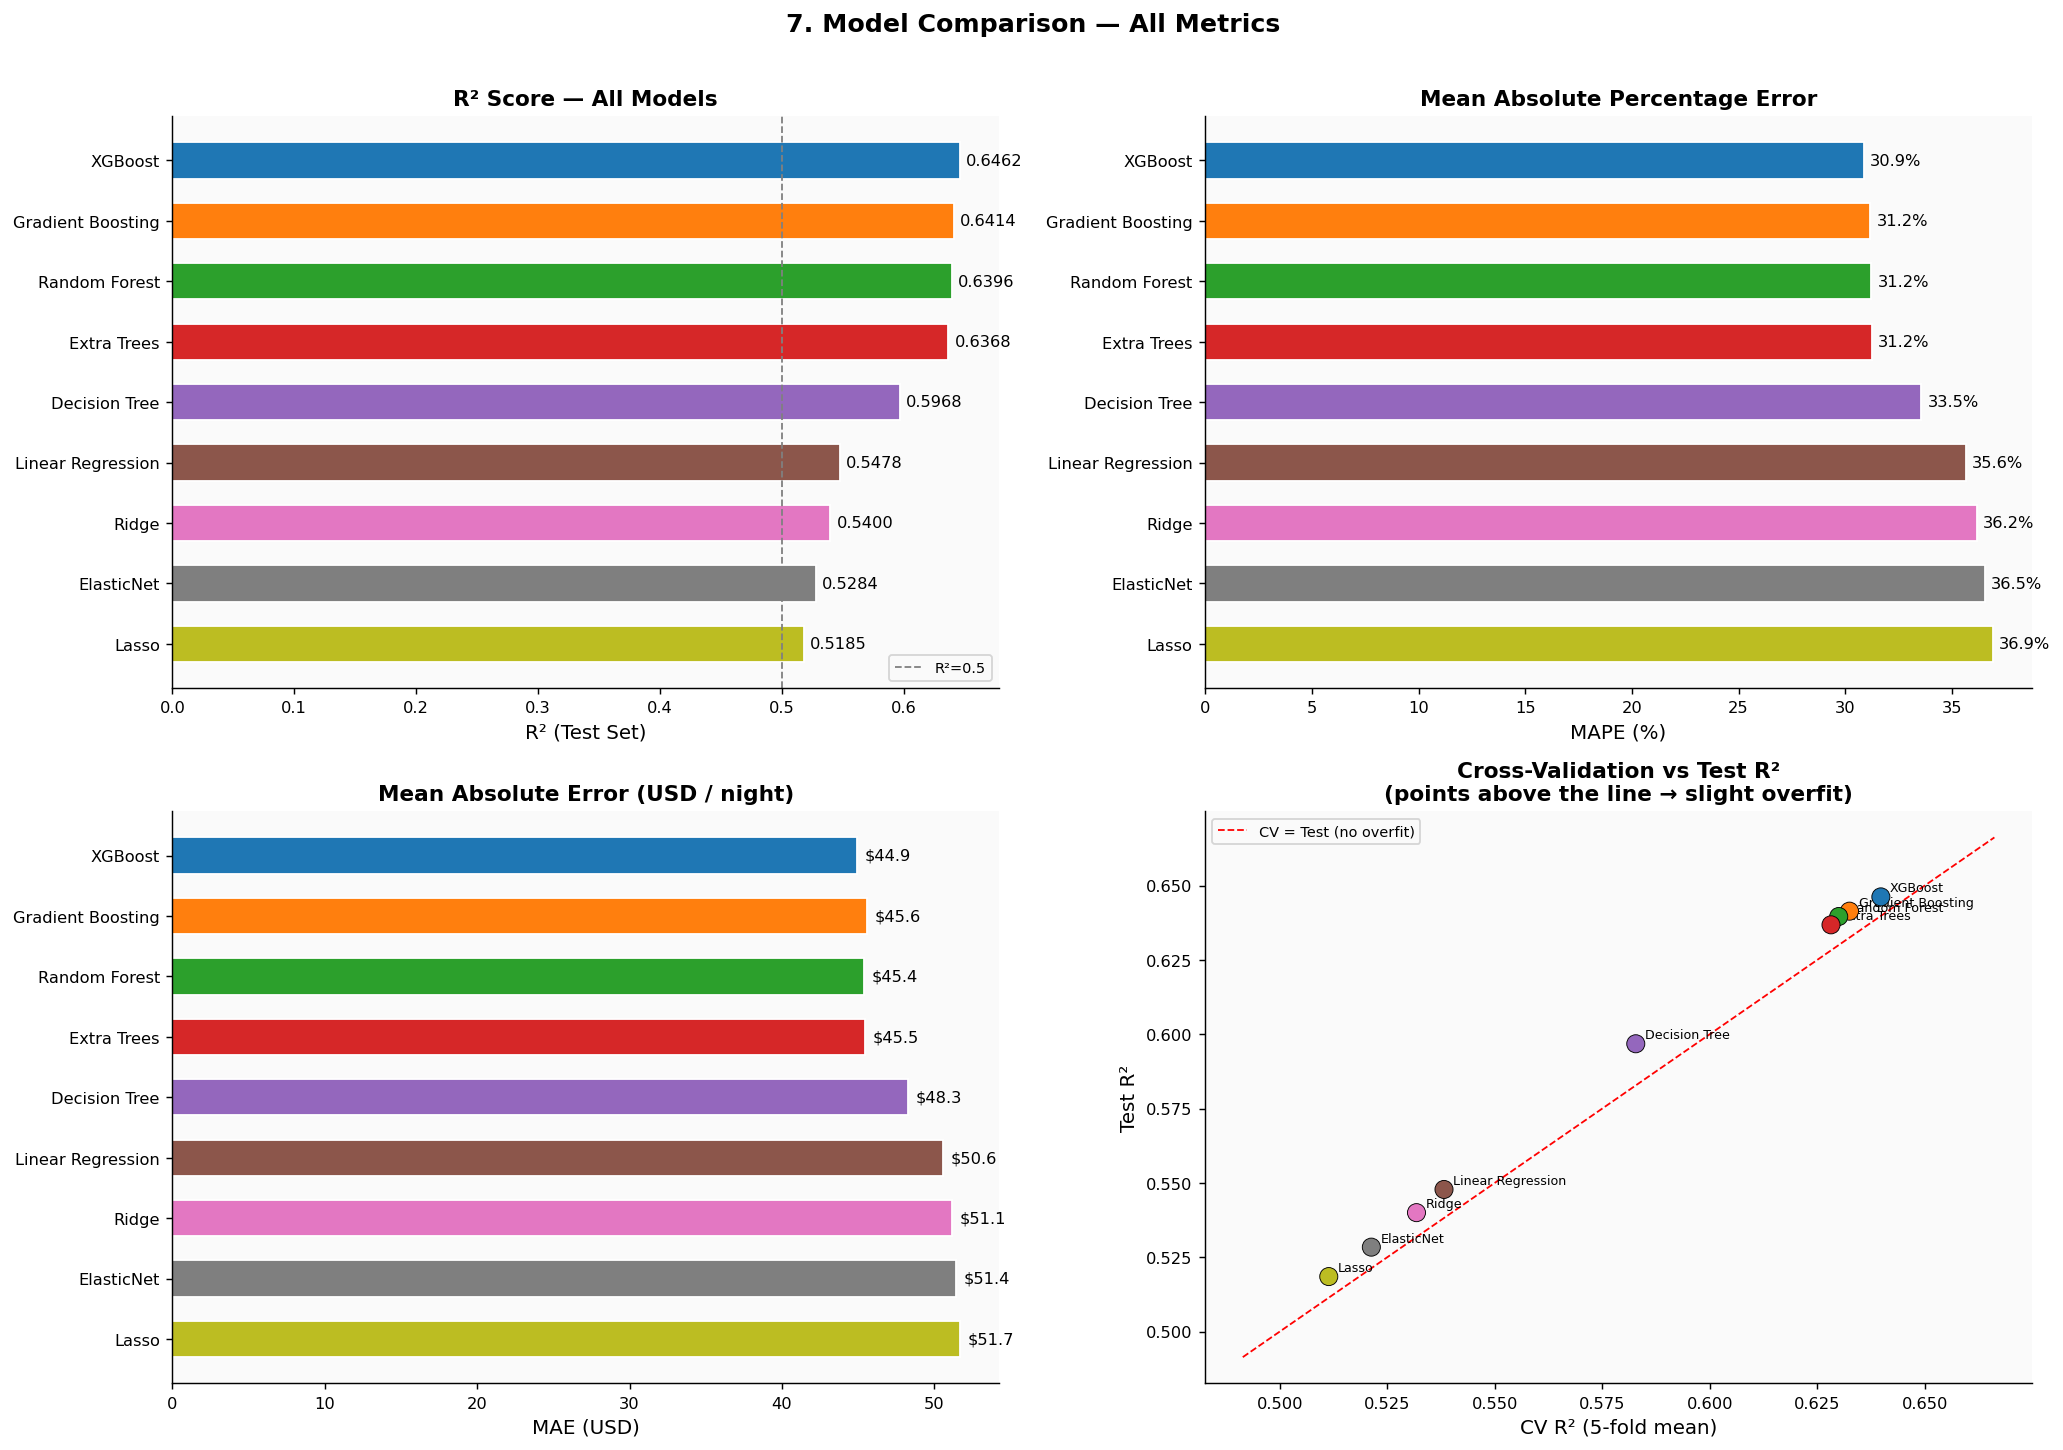

In [51]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7D — MODEL COMPARISON CHARTS
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

palette = sns.color_palette('tab10', len(results_df))

# 1) R² bar
axes[0,0].barh(results_df['Model'][::-1], results_df['Test R²'][::-1],
               color=palette[::-1], edgecolor='white', height=0.6)
axes[0,0].axvline(0.5, color='grey', linestyle='--', linewidth=1, label='R²=0.5')
axes[0,0].set_xlabel('R² (Test Set)')
axes[0,0].set_title('R² Score — All Models')
axes[0,0].legend(fontsize=8)
for i, v in enumerate(results_df['Test R²'][::-1]):
    axes[0,0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# 2) MAPE bar
axes[0,1].barh(results_df['Model'][::-1], results_df['MAPE (%)'][::-1],
               color=palette[::-1], edgecolor='white', height=0.6)
axes[0,1].set_xlabel('MAPE (%)')
axes[0,1].set_title('Mean Absolute Percentage Error')
for i, v in enumerate(results_df['MAPE (%)'][::-1]):
    axes[0,1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# 3) MAE $ bar
axes[1,0].barh(results_df['Model'][::-1], results_df['MAE ($)'][::-1],
               color=palette[::-1], edgecolor='white', height=0.6)
axes[1,0].set_xlabel('MAE (USD)')
axes[1,0].set_title('Mean Absolute Error (USD / night)')
for i, v in enumerate(results_df['MAE ($)'][::-1]):
    axes[1,0].text(v + 0.5, i, f'${v:.1f}', va='center', fontsize=9)

# 4) CV vs Test R² scatter
axes[1,1].scatter(results_df['CV R² (mean)'], results_df['Test R²'],
                  color=palette, s=100, zorder=5, edgecolors='k', linewidths=0.5)
for _, row in results_df.iterrows():
    axes[1,1].annotate(row['Model'], (row['CV R² (mean)'], row['Test R²']),
                       textcoords='offset points', xytext=(5, 3), fontsize=7)
lims = [min(results_df['CV R² (mean)'].min(), results_df['Test R²'].min()) - 0.02,
        max(results_df['CV R² (mean)'].max(), results_df['Test R²'].max()) + 0.02]
axes[1,1].plot(lims, lims, 'r--', linewidth=1, label='CV = Test (no overfit)')
axes[1,1].set_xlabel('CV R² (5-fold mean)')
axes[1,1].set_ylabel('Test R²')
axes[1,1].set_title('Cross-Validation vs Test R²\n(points above the line → slight overfit)')
axes[1,1].legend(fontsize=8)

plt.suptitle('7. Model Comparison — All Metrics', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()


🏆 Best Model: XGBoost  (Test R² = 0.6462)


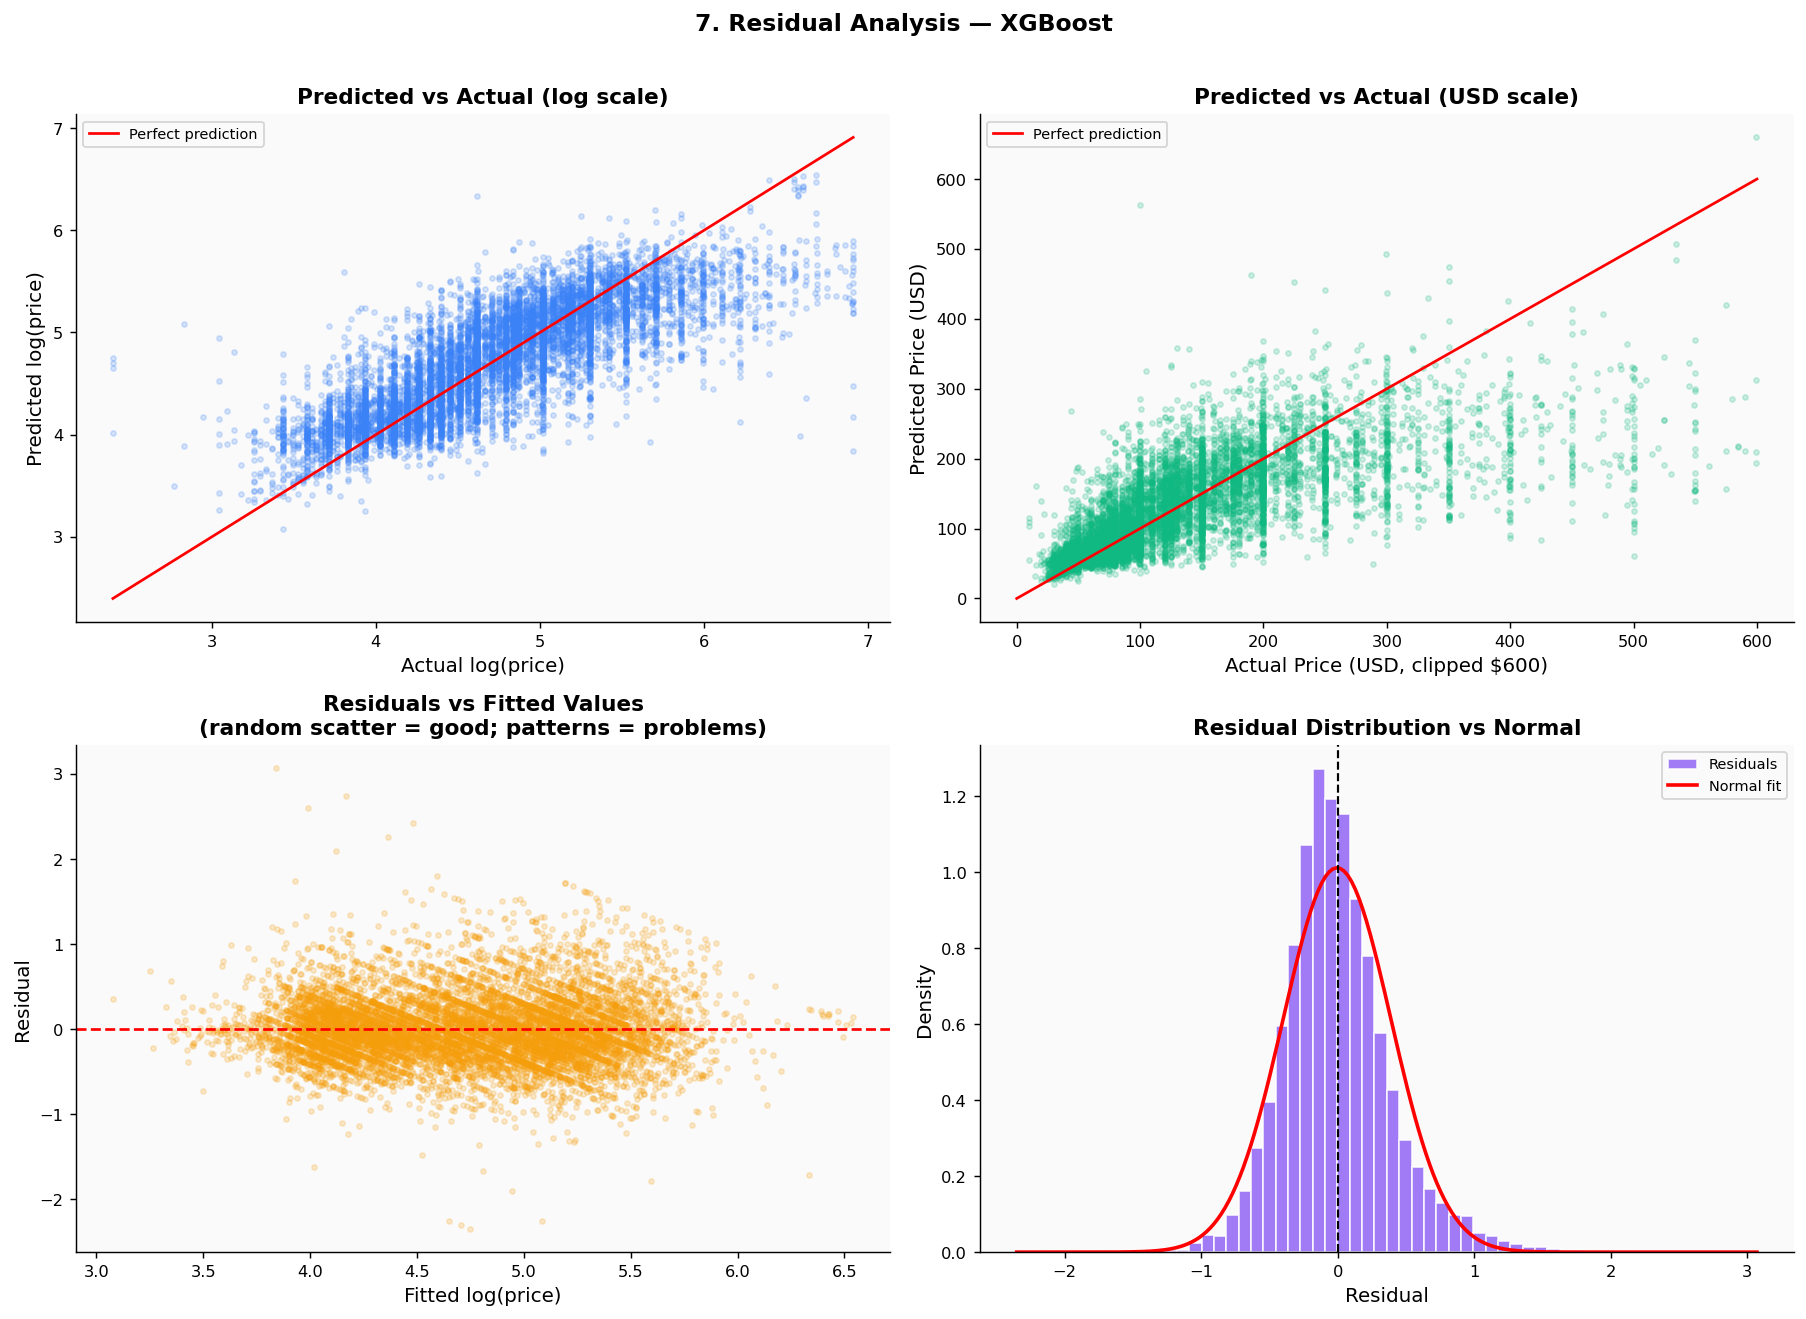

Residual statistics:
  Mean residual  : -0.0052  (ideal: 0.0)
  Std residual   : 0.3946
  Shapiro-Wilk p : 0.0000  (not normal — expected for large n)
  MAE ($)        : $44.93
  MAPE           : 30.87%


In [52]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7E — BEST MODEL RESIDUAL ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
best_name  = results_df.iloc[0]['Model']
best_model = fitted[best_name]
print(f"🏆 Best Model: {best_name}  (Test R² = {results_df.iloc[0]['Test R²']:.4f})")

is_linear = best_name in LINEAR_MODELS
Xte_b = X_test_sc if is_linear else X_test.values

y_pred_log = best_model.predict(Xte_b)
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test)
residuals  = y_test.values - y_pred_log

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Predicted vs Actual (log scale)
axes[0,0].scatter(y_test, y_pred_log, alpha=0.2, s=8, color='#3B82F6')
lims = [min(y_test.min(), y_pred_log.min()),
        max(y_test.max(), y_pred_log.max())]
axes[0,0].plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
axes[0,0].set_xlabel('Actual log(price)')
axes[0,0].set_ylabel('Predicted log(price)')
axes[0,0].set_title('Predicted vs Actual (log scale)')
axes[0,0].legend(fontsize=8)

# 2) Predicted vs Actual (USD scale, clipped)
clip = 600
mask_plot = y_test_usd.values < clip
axes[0,1].scatter(y_test_usd.values[mask_plot], y_pred_usd[mask_plot],
                   alpha=0.2, s=8, color='#10B981')
axes[0,1].plot([0, clip], [0, clip], 'r-', linewidth=1.5, label='Perfect prediction')
axes[0,1].set_xlabel('Actual Price (USD, clipped $600)')
axes[0,1].set_ylabel('Predicted Price (USD)')
axes[0,1].set_title('Predicted vs Actual (USD scale)')
axes[0,1].legend(fontsize=8)

# 3) Residuals vs Fitted
axes[1,0].scatter(y_pred_log, residuals, alpha=0.2, s=8, color='#F59E0B')
axes[1,0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[1,0].set_xlabel('Fitted log(price)')
axes[1,0].set_ylabel('Residual')
axes[1,0].set_title('Residuals vs Fitted Values\n(random scatter = good; patterns = problems)')

# 4) Residual histogram + KDE
axes[1,1].hist(residuals, bins=60, density=True, color='#8B5CF6',
               edgecolor='white', alpha=0.8, label='Residuals')
xs = np.linspace(residuals.min(), residuals.max(), 200)
axes[1,1].plot(xs, stats.norm.pdf(xs, residuals.mean(), residuals.std()),
               color='red', linewidth=2, label='Normal fit')
axes[1,1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1,1].set_xlabel('Residual')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution vs Normal')
axes[1,1].legend(fontsize=8)

sw_stat, sw_p = stats.shapiro(np.random.choice(residuals, min(5000, len(residuals)), replace=False))

plt.suptitle(f'7. Residual Analysis — {best_name}', fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"  Mean residual  : {residuals.mean():.4f}  (ideal: 0.0)")
print(f"  Std residual   : {residuals.std():.4f}")
print(f"  Shapiro-Wilk p : {sw_p:.4f}  ({'approx. normal' if sw_p > 0.05 else 'not normal — expected for large n'})")
print(f"  MAE ($)        : ${mean_absolute_error(y_test_usd, y_pred_usd):.2f}")
print(f"  MAPE           : {mean_absolute_percentage_error(y_test_usd, y_pred_usd)*100:.2f}%")


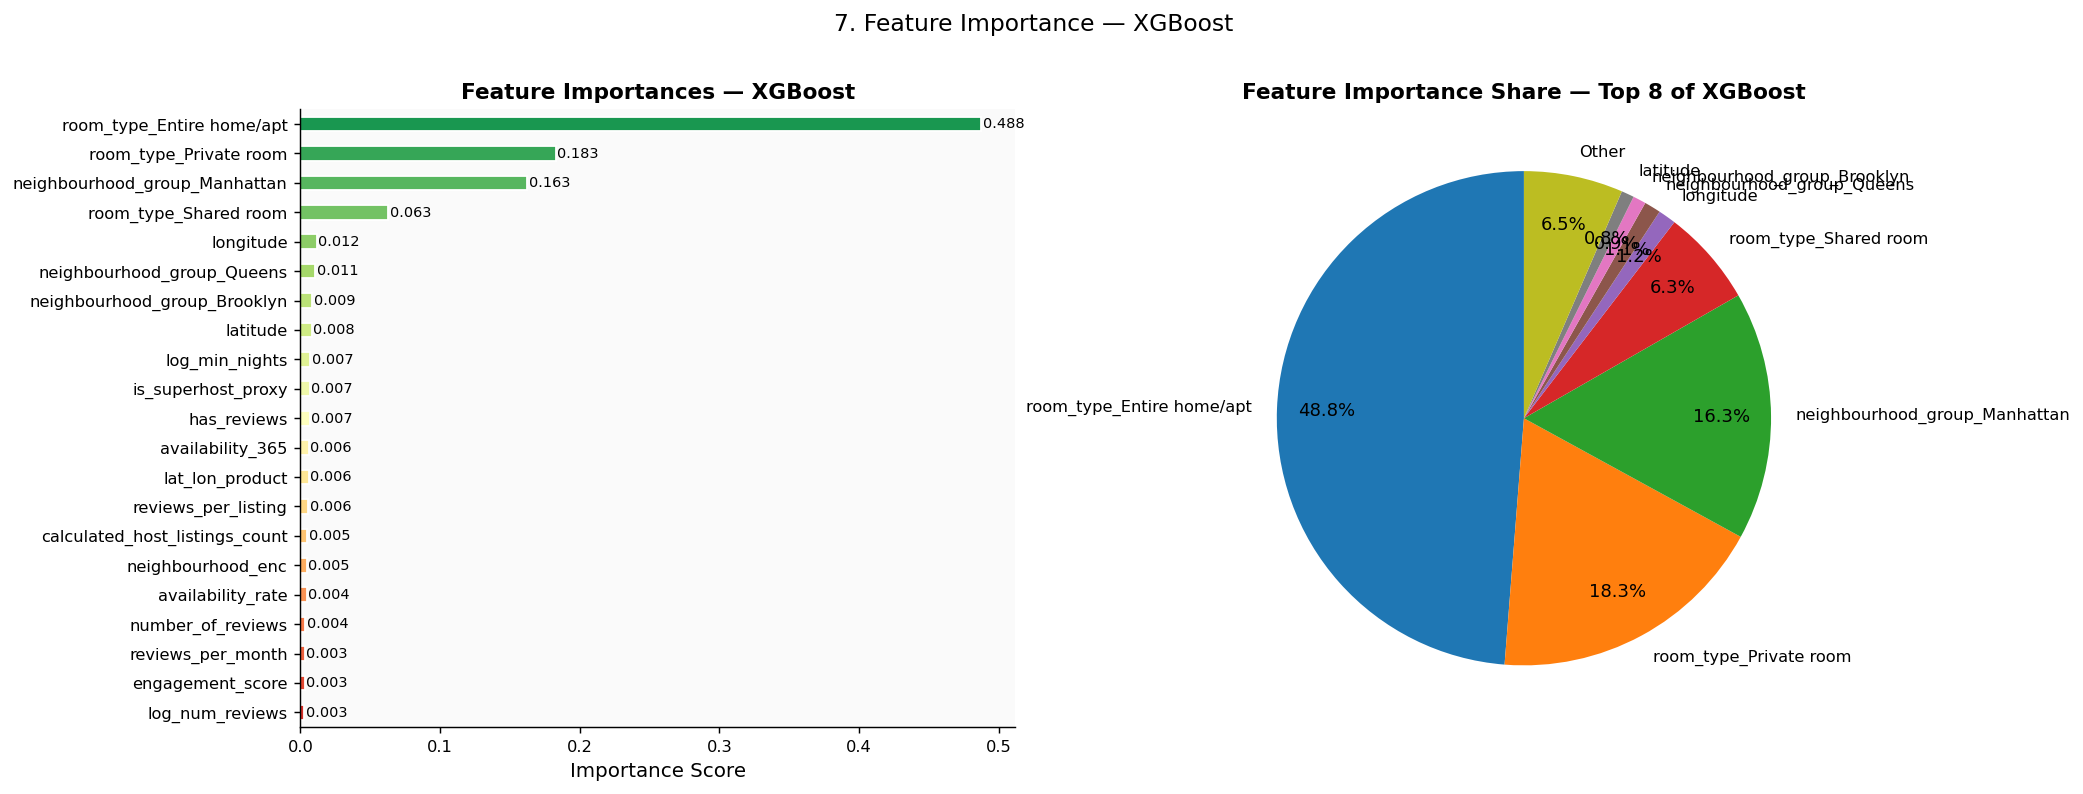

Top 5 most important features:
  room_type_Entire home/apt                    : 0.4875 (48.8%)
  room_type_Private room                       : 0.1828 (18.3%)
  neighbourhood_group_Manhattan                : 0.1625 (16.3%)
  room_type_Shared room                        : 0.0630 (6.3%)
  longitude                                    : 0.0117 (1.2%)


In [53]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7F — FEATURE IMPORTANCE OF BEST MODEL
# ─────────────────────────────────────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=SELECTED_FEATURES)
    fi_sorted = fi.sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Horizontal bar
    colors_imp = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(fi_sorted)))
    fi_sorted.plot(kind='barh', ax=axes[0], color=colors_imp, edgecolor='white')
    axes[0].set_title(f'Feature Importances — {best_name}')
    axes[0].set_xlabel('Importance Score')
    for i, (feat, val) in enumerate(fi_sorted.items()):
        axes[0].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=8)

    # Pie chart — top 8
    top8 = fi.sort_values(ascending=False).head(8)
    other = fi.sum() - top8.sum()
    pie_vals = list(top8.values) + [other]
    pie_labels = list(top8.index) + ['Other']
    axes[1].pie(pie_vals, labels=pie_labels, autopct='%1.1f%%',
                startangle=90, pctdistance=0.8,
                colors=sns.color_palette('tab10', len(pie_vals)))
    axes[1].set_title(f'Feature Importance Share — Top 8 of {best_name}')

    plt.suptitle(f'7. Feature Importance — {best_name}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print("Top 5 most important features:")
    for feat, imp in fi.sort_values(ascending=False).head(5).items():
        print(f"  {feat:45s}: {imp:.4f} ({imp/fi.sum()*100:.1f}%)")
else:
    # For linear models, use coefficients
    coefs = pd.Series(np.abs(best_model.coef_), index=SELECTED_FEATURES).sort_values(ascending=True)
    coefs.plot(kind='barh', figsize=(10, 6), title=f'Coefficient Magnitudes — {best_name}')
    plt.tight_layout()
    plt.show()


## 8. Hyperparameter Tuning

The default hyperparameters used in Section 7 are reasonable starting points, but the best
model can often be improved through systematic search. We apply **GridSearchCV** with
5-fold cross-validation to tune the top model.

### Why GridSearchCV?
GridSearchCV exhaustively evaluates every combination of specified hyperparameters, using
cross-validation to estimate generalisation performance for each combination. This avoids
"peeking" at the test set during tuning — the test set is only used once, at the very end.

### Hyperparameters tuned (XGBoost / LightGBM / Random Forest)

| Parameter | Values Searched | Effect |
|---|---|---|
| `n_estimators` | [200, 400] | More trees = better fit, but slower |
| `max_depth` | [4, 6, 8] | Deeper trees = more complex patterns, more overfit risk |
| `learning_rate` | [0.03, 0.05] | Lower = more trees needed, but better generalisation |
| `subsample` | [0.7, 0.9] | Row sampling per tree — reduces overfitting |
| `colsample_bytree` | [0.7, 0.9] | Feature sampling per tree — reduces overfitting |

> **Note:** A coarser grid is used here to keep runtime manageable. In production, use
> `RandomizedSearchCV` or Bayesian optimisation (Optuna) for wider search at lower cost.


In [54]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8 — HYPERPARAMETER TUNING (GridSearchCV on best model)
# ─────────────────────────────────────────────────────────────────────────────

is_linear_best = best_name in LINEAR_MODELS
Xtr_tune = X_train_sc if is_linear_best else X_train.values
Xte_tune = X_test_sc  if is_linear_best else X_test.values

# Define grid based on which model won
if 'XGBoost' in best_name and XGBOOST_AVAILABLE:
    tune_model = XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse',
                               verbosity=0, n_jobs=-1)
    param_grid = {
        'n_estimators'    : [300, 500],
        'max_depth'       : [5, 6, 7],
        'learning_rate'   : [0.03, 0.05],
        'subsample'       : [0.8, 0.9],
        'colsample_bytree': [0.8],
    }
elif 'LightGBM' in best_name and LIGHTGBM_AVAILABLE:
    tune_model = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    param_grid = {
        'n_estimators'  : [300, 500],
        'max_depth'     : [5, 6, 7],
        'learning_rate' : [0.03, 0.05],
        'subsample'     : [0.8, 0.9],
    }
elif 'Random Forest' in best_name:
    tune_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
    param_grid = {
        'n_estimators'   : [200, 400],
        'max_depth'      : [12, 15, 18],
        'min_samples_leaf': [5, 10],
    }
else:
    # Fallback: tune Ridge
    tune_model = Ridge()
    param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
    Xtr_tune   = X_train_sc
    Xte_tune   = X_test_sc

print(f"Tuning: {best_name}")
print(f"Grid: {param_grid}")
print(f"Combinations: {1}")
total = 1
for vals in param_grid.values():
    total *= len(vals)
print(f"Total combinations: {total}  ×  {CV_FOLDS} folds = {total * CV_FOLDS} fits")

t0 = time.time()
grid_search = GridSearchCV(tune_model, param_grid, cv=CV_FOLDS,
                            scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(Xtr_tune, y_train)
elapsed = time.time() - t0

print(f"\n✅ Tuning complete in {elapsed:.1f}s")
print(f"   Best parameters : {grid_search.best_params_}")
print(f"   Best CV R²      : {grid_search.best_score_:.4f}")

# Evaluate tuned model
y_pred_tuned_log = grid_search.best_estimator_.predict(Xte_tune)
y_pred_tuned_usd = np.expm1(y_pred_tuned_log)
r2_tuned    = r2_score(y_test, y_pred_tuned_log)
mae_tuned   = mean_absolute_error(y_test, y_pred_tuned_log)
mape_tuned  = mean_absolute_percentage_error(np.expm1(y_test), y_pred_tuned_usd) * 100
mae_usd_tun = mean_absolute_error(np.expm1(y_test), y_pred_tuned_usd)

print(f"\n── Tuned Model Performance ──────────────────────────────────────")
print(f"   Test R²    : {r2_tuned:.4f}  (was {results_df.iloc[0]['Test R²']:.4f})")
print(f"   MAE (log)  : {mae_tuned:.4f}  (was {results_df.iloc[0]['MAE (log)']:.4f})")
print(f"   MAE ($)    : ${mae_usd_tun:.2f}")
print(f"   MAPE       : {mape_tuned:.2f}%  (was {results_df.iloc[0]['MAPE (%)']:.2f}%)")

# Use tuned model going forward
best_model = grid_search.best_estimator_
BEST_PARAMS = grid_search.best_params_
BEST_R2     = r2_tuned
BEST_MAPE   = mape_tuned
BEST_MAE    = mae_usd_tun


Tuning: XGBoost
Grid: {'n_estimators': [300, 500], 'max_depth': [5, 6, 7], 'learning_rate': [0.03, 0.05], 'subsample': [0.8, 0.9], 'colsample_bytree': [0.8]}
Combinations: 1
Total combinations: 24  ×  5 folds = 120 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Tuning complete in 142.4s
   Best parameters : {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}
   Best CV R²      : 0.6417

── Tuned Model Performance ──────────────────────────────────────
   Test R²    : 0.6480  (was 0.6462)
   MAE (log)  : 0.2929  (was 0.2943)
   MAE ($)    : $44.78
   MAPE       : 30.76%  (was 30.87%)


## 9. Saving the Best Model

Once we have identified and tuned the best model, we save three artefacts to disk:

1. **`models/best_model.pkl`** — the fully trained, tuned model object. Loading this with
   `joblib.load()` gives back a ready-to-predict estimator without retraining.
2. **`models/scaler.pkl`** — the `RobustScaler` fitted on training data. This must be applied
   to any new input data before feeding it to linear models. Tree-based models do not require
   scaling, but we save it for completeness and future use.
3. **`models/feature_names.pkl`** — the ordered list of feature names. This ensures that
   any new data is aligned to the same columns in the same order as the training data.

### Reproducibility Note
The three saved artefacts together constitute a complete, self-contained prediction system.
Any analyst can load them and produce identical predictions without access to the training data.


In [55]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9 — SAVE MODEL ARTEFACTS
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

joblib.dump(best_model,        'models/best_model.pkl')
joblib.dump(scaler,            'models/scaler.pkl')
joblib.dump(SELECTED_FEATURES, 'models/feature_names.pkl')
joblib.dump(results_df,        'models/results_summary.pkl')

print("✅ Model artefacts saved:")
print(f"   models/best_model.pkl      → {best_name} (tuned)")
print(f"   models/scaler.pkl          → RobustScaler ({len(SELECTED_FEATURES)} features)")
print(f"   models/feature_names.pkl   → {len(SELECTED_FEATURES)} feature names")
print(f"   models/results_summary.pkl → full results table")
print(f"\nFinal model performance:")
print(f"   R²      : {BEST_R2:.4f}")
print(f"   MAE ($) : ${BEST_MAE:.2f} per night")
print(f"   MAPE    : {BEST_MAPE:.2f}%")


✅ Model artefacts saved:
   models/best_model.pkl      → XGBoost (tuned)
   models/scaler.pkl          → RobustScaler (21 features)
   models/feature_names.pkl   → 21 feature names
   models/results_summary.pkl → full results table

Final model performance:
   R²      : 0.6480
   MAE ($) : $44.78 per night
   MAPE    : 30.76%


## 10. Interactive Price Prediction

This section uses the saved model to predict the nightly price for a **new listing**.

### How to use
Run the cell below. You will be prompted to enter:
- Geographic location (latitude & longitude)
- Borough and room type
- Booking characteristics (minimum nights, reviews, availability)

The model will return a predicted nightly price in USD.

### Input Validation
- If you leave a field blank, a sensible default value is used
- Borough and room type inputs are matched case-insensitively
- Invalid numbers default to the median value from the training data

### Interpreting the Output
The prediction is a **point estimate** — a single best-guess price. Due to the inherent
variability in Airbnb pricing, the actual market rate could reasonably be ±25–40% of this
estimate. The confidence interval should be interpreted alongside the model's MAPE.


In [56]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10 — INTERACTIVE PRICE PREDICTION
# ─────────────────────────────────────────────────────────────────────────────
import joblib, numpy as np, pandas as pd

_model    = joblib.load('models/best_model.pkl')

# Guard: BEST_MAPE / BEST_R2 / BEST_MAE are set in Section 8.
# If Section 8 was skipped, fall back to the untuned best result.
if 'BEST_MAPE' not in dir():
    BEST_MAPE = results_df.iloc[0]['MAPE (%)']
if 'BEST_R2'   not in dir():
    BEST_R2   = results_df.iloc[0]['Test R²']
if 'BEST_MAE'  not in dir():
    BEST_MAE  = results_df.iloc[0]['MAE ($)']
if 'best_name' not in dir():
    best_name = results_df.iloc[0]['Model']

_scaler   = joblib.load('models/scaler.pkl')
_features = joblib.load('models/feature_names.pkl')

# Median defaults from training data (used when user leaves field blank)
DEFAULTS = {
    'latitude'                      : 40.7282,
    'longitude'                     : -73.9942,
    'minimum_nights'                : 3,
    'number_of_reviews'             : 23,
    'reviews_per_month'             : 1.37,
    'calculated_host_listings_count': 1,
    'availability_365'              : 225,
}

def prompt_float(msg, default):
    try:
        v = input(msg).strip()
        return float(v) if v else default
    except:
        return default

def prompt_int(msg, default):
    try:
        v = input(msg).strip()
        return int(v) if v else default
    except:
        return default

# ─── User Inputs ─────────────────────────────────────────────────────────────
print("=" * 60)
print("   🏠  Airbnb NYC — Nightly Price Predictor")
print("=" * 60)
print("  (Press ENTER to use default values)")

latitude          = prompt_float(f"  Latitude     (default {DEFAULTS['latitude']})   : ", DEFAULTS['latitude'])
longitude         = prompt_float(f"  Longitude    (default {DEFAULTS['longitude']}) : ", DEFAULTS['longitude'])
minimum_nights    = prompt_int  (f"  Min nights   (default {DEFAULTS['minimum_nights']})         : ", DEFAULTS['minimum_nights'])
num_reviews       = prompt_int  (f"  # Reviews    (default {DEFAULTS['number_of_reviews']})        : ", DEFAULTS['number_of_reviews'])
reviews_per_month = prompt_float(f"  Rev/month    (default {DEFAULTS['reviews_per_month']})       : ", DEFAULTS['reviews_per_month'])
host_count        = prompt_int  (f"  Host listings(default {DEFAULTS['calculated_host_listings_count']})         : ", DEFAULTS['calculated_host_listings_count'])
availability      = prompt_int  (f"  Availability (default {DEFAULTS['availability_365']})       : ", DEFAULTS['availability_365'])

print("  Room type options: Entire home/apt | Private room | Shared room")
room_type_raw = input("  Room type    (default: Private room)    : ").strip() or 'Private room'

print(" Borough options : Manhattan | Brooklyn | Queens | Bronx | Staten Island")
borough_raw = input("  Borough      (default: Brooklyn)        : ").strip() or 'Brooklyn'

# ─── Input Validation ───────────────────────────────────────────────────────
# NYC bounding box (approx): lat 40.49 – 40.92, lon -74.26 – -73.68
if not (40.49 <= latitude <= 40.92):
    print(f"⚠  Latitude {latitude} is outside NYC range (40.49–40.92). Clamping.")
    latitude = np.clip(latitude, 40.49, 40.92)
if not (-74.26 <= longitude <= -73.68):
    print(f"⚠  Longitude {longitude} is outside NYC range (-74.26– -73.68). Clamping.")
    longitude = np.clip(longitude, -74.26, -73.68)
if minimum_nights < 1:
    print(f"⚠  minimum_nights must be ≥ 1. Resetting to 1.")
    minimum_nights = 1
if num_reviews < 0:
    print(f"⚠  number_of_reviews cannot be negative. Resetting to 0.")
    num_reviews = 0
if not (0 <= availability <= 365):
    print(f"⚠  Availability must be 0–365. Clamping.")
    availability = int(np.clip(availability, 0, 365))
valid_room_types = ['Entire home/apt', 'Private room', 'Shared room']
if not any(r in room_type_raw for r in ['Entire', 'Private', 'Shared']):
    print(f"⚠  Unrecognised room type '{room_type_raw}'. Defaulting to 'Private room'.")
    room_type_raw = 'Private room'
valid_boroughs = ['Manhattan', 'Brooklyn', 'Queens', 'Bronx', 'Staten']
if not any(b in borough_raw for b in valid_boroughs):
    print(f"⚠  Unrecognised borough '{borough_raw}'. Defaulting to 'Brooklyn'.")
    borough_raw = 'Brooklyn'

# ─── Build Feature Row ────────────────────────────────────────────────────────
row = {
    'latitude'                        : latitude,
    'longitude'                       : longitude,
    'minimum_nights'                  : minimum_nights,
    'number_of_reviews'               : num_reviews,
    'reviews_per_month'               : reviews_per_month,
    'calculated_host_listings_count'  : host_count,
    'availability_365'                : availability,
    'neighbourhood_enc'               : 0,

    # Borough one-hot
    'neighbourhood_group_Bronx'         : int('Bronx'       in borough_raw),
    'neighbourhood_group_Brooklyn'      : int('Brooklyn'    in borough_raw),
    'neighbourhood_group_Manhattan'     : int('Manhattan'   in borough_raw),
    'neighbourhood_group_Queens'        : int('Queens'      in borough_raw),
    'neighbourhood_group_Staten Island' : int('Staten'      in borough_raw),

    # Room type one-hot
    'room_type_Entire home/apt' : int('Entire' in room_type_raw),
    'room_type_Private room'    : int('Private' in room_type_raw),
    'room_type_Shared room'     : int('Shared' in room_type_raw),

    # Engineered features
    'log_min_nights'        : np.log1p(minimum_nights),
    'log_num_reviews'       : np.log1p(num_reviews),
    'reviews_per_listing'   : num_reviews / max(host_count, 1),
    'availability_rate'     : availability / 365,
    'has_reviews'           : int(num_reviews > 0),
    'is_superhost_proxy'    : int(host_count > 3),
    'engagement_score'      : reviews_per_month * (availability / 365),
    'lat_lon_product'       : latitude * abs(longitude),
}

input_df = pd.DataFrame([row])
for col in _features:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[_features]

# ─── Predict ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
if isinstance(_model, (LinearRegression, Ridge, Lasso, ElasticNet)):
    arr = _scaler.transform(input_df)
else:
    arr = input_df.values

log_pred   = _model.predict(arr)[0]
price_pred = np.expm1(log_pred)

# Confidence interval (±1 MAPE)
mape_rate  = BEST_MAPE / 100
low_est    = price_pred * (1 - mape_rate)
high_est   = price_pred * (1 + mape_rate)

print("\n" + "=" * 60)
print(f"   💵  Predicted Nightly Price : ${price_pred:,.2f} USD")
print(f"   📊  Estimated Range         : ${low_est:,.2f} – ${high_est:,.2f}")
print(f"        (±{BEST_MAPE:.1f}% model MAPE)")
print("=" * 60)

print("\n📋 Listing Input Summary:")
print(f"   Room type    : {room_type_raw}")
print(f"   Borough      : {borough_raw}")
print(f"   Location     : ({latitude:.4f}, {longitude:.4f})")
print(f"   Min nights   : {minimum_nights}")
print(f"   Reviews      : {num_reviews} total ({reviews_per_month}/month)")
print(f"   Host listings: {host_count}")
print(f"   Availability : {availability} days/year ({availability/365*100:.0f}%)")


   🏠  Airbnb NYC — Nightly Price Predictor
  (Press ENTER to use default values)
  Room type options: Entire home/apt | Private room | Shared room
 Borough options : Manhattan | Brooklyn | Queens | Bronx | Staten Island

   💵  Predicted Nightly Price : $91.45 USD
   📊  Estimated Range         : $63.31 – $119.58
        (±30.8% model MAPE)

📋 Listing Input Summary:
   Room type    : Private room
   Borough      : Brooklyn
   Location     : (34.5600, -45.5400)
   Min nights   : 3
   Reviews      : 34 total (100.0/month)
   Host listings: 1000
   Availability : 235 days/year (64%)
